# 자전거 대여 데이터를 분석한 수요 예측 모델 최적화

자전거 대여 시스템의 운영을 최적화하기 위해 자전거 대여 데이터를 분석하고,  
분석된 데이터를 학습한 머신러닝 모델을 통해 가장 정확한 수요 예측 모델을 개발합니다.

## 1. 데이터 준비

먼저 분석에 사용될 데이터를 담고 있는 train.csv와  
학습된 모델의 성능을 측정할 데이터를 담고 있는 test.csv의 내용을 불러와,  
pandas DataFrame에 로드시킵니다.  
일시(datetime)의 경우는 문자열로 읽히는 것이 기본 동작이기 때문에,  
데이터를 로드한 직후 astype('datetime64[ns]')을 통해 날짜형태로 변경합니다.  
  
또한 분석 도중 사용할 그래프의 해석을 돕기위해,  
한글 폰트인 NanumGothic(나눔고딕)을 matplotlib.pyplot의 폰트로 설정합니다.

In [ ]:
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error

import numpy as np

FONT_PATH = 'NanumGothic.ttf'

train_df = None
test_df = None

def initialize():
    fm.fontManager.addfont(FONT_PATH)

    plt.rcParams['font.family'] = 'NanumGothic'
    plt.rcParams['axes.unicode_minus'] = False
    
    train_df = pd.read_csv('train.csv')
    test_df = pd.read_csv('test.csv')
    
    train_df['datetime'] = pd.to_datetime(train_df['datetime'])
    test_df['datetime'] = pd.to_datetime(test_df['datetime'])
    
    return train_df, test_df

train_df, test_df = initialize()

# train_df 정보 출력
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[us]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
dtypes: datetime64[us](1), float64(3), int64(8)
memory usage: 1020.7 KB


In [201]:
train_df.isna().sum()

datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64

In [202]:
test_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6493 entries, 0 to 6492
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    6493 non-null   datetime64[us]
 1   season      6493 non-null   int64         
 2   holiday     6493 non-null   int64         
 3   workingday  6493 non-null   int64         
 4   weather     6493 non-null   int64         
 5   temp        6493 non-null   float64       
 6   atemp       6493 non-null   float64       
 7   humidity    6493 non-null   int64         
 8   windspeed   6493 non-null   float64       
dtypes: datetime64[us](1), float64(3), int64(5)
memory usage: 456.7 KB


In [203]:
test_df.isna().sum()

datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
dtype: int64

결측값 없이, 데이터의 준비가 잘 완료되었습니다

## 2. 데이터 분석
데이터를 조사하여 count에 영향을 주는 요소들이 무엇인지 추정합니다.  
우선, train_df 를 복제하여 별도의 df 를 생성합니다.

In [204]:
analize_df = train_df.copy()

analize_df['year'] = analize_df['datetime'].dt.year
analize_df['month'] = analize_df['datetime'].dt.month
analize_df['hour'] = analize_df['datetime'].dt.hour
analize_df['dayofweek'] = analize_df['datetime'].dt.dayofweek

### 1) 시간대 별 자전거 대여 패턴
시간대별 대여량의 평균적인 흐름을 살핍니다.

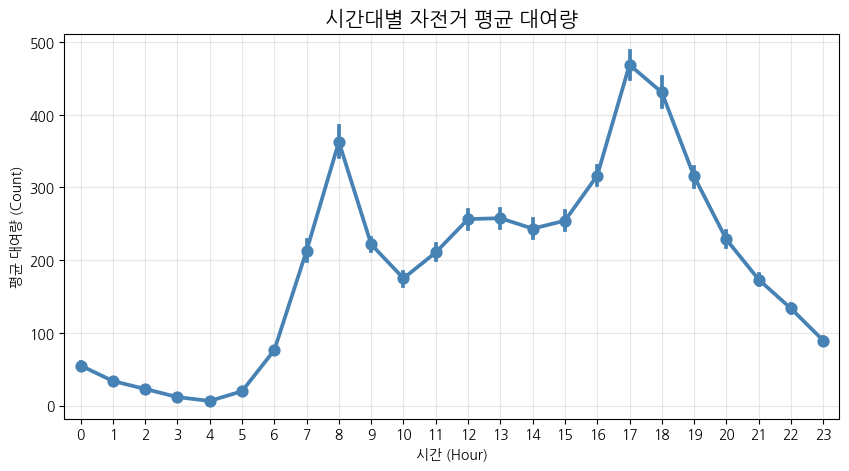

In [205]:
plt.figure(figsize=(10, 5))
sns.pointplot(data=analize_df, x='hour', y='count', color='steelblue')
plt.title('시간대별 자전거 평균 대여량', fontsize=15)
plt.xlabel('시간 (Hour)')
plt.ylabel('평균 대여량 (Count)')
plt.grid(True, alpha=0.3)
plt.show()

### 2) 날씨 변수와 자전거 대여 수요 간의 상관관계
날씨는 범주형(1: 맑음 ~ 4: 폭우/폭설) 변수이므로 막대그래프로 차이를 확인하고,  
추가로 온도(temp), 습도(humidity) 등 수치형 날씨 변수들과의 상관계수를 히트맵으로 확인합니다.

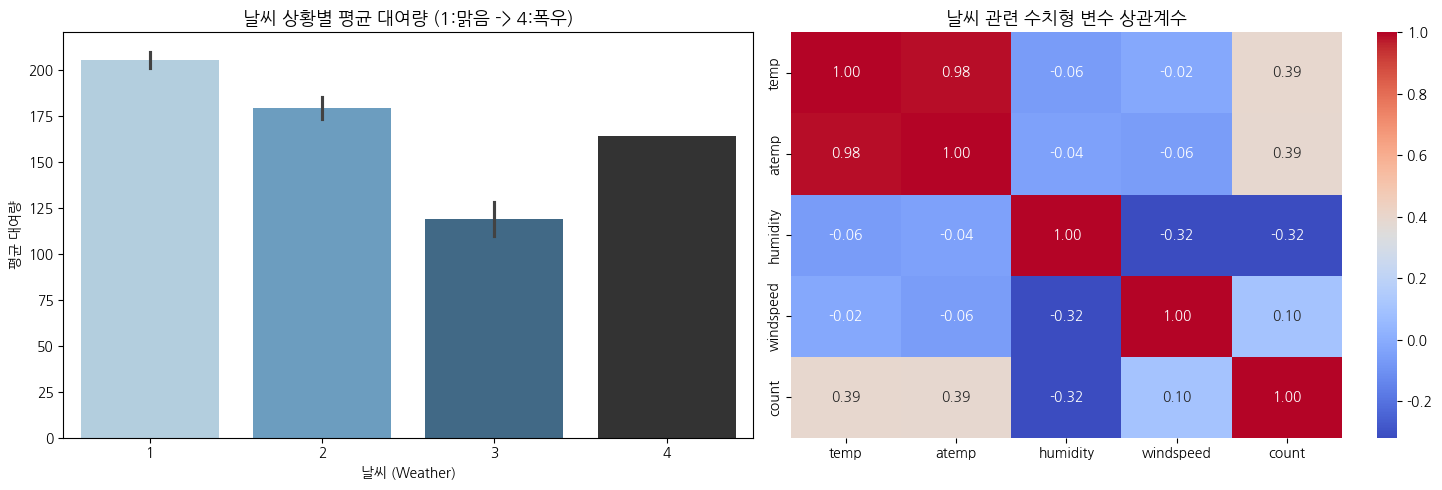

In [206]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. 날씨(weather) 범주에 따른 대여량
sns.barplot(data=analize_df, x='weather', y='count', ax=axes[0], palette='Blues_d', hue='weather', legend=False)
axes[0].set_title('날씨 상황별 평균 대여량 (1:맑음 -> 4:폭우)', fontsize=13)
axes[0].set_xlabel('날씨 (Weather)')
axes[0].set_ylabel('평균 대여량')

# 2. 수치형 날씨 변수와의 상관관계 히트맵
weather_cols = ['temp', 'atemp', 'humidity', 'windspeed', 'count']
corr = analize_df[weather_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1])
axes[1].set_title('날씨 관련 수치형 변수 상관계수', fontsize=13)

plt.tight_layout()
plt.show()

### 3) 계절별 자전거 대여 패턴의 차이
계절(season)별 전체 대여량의 차이를 막대그래프로 확인합니다.

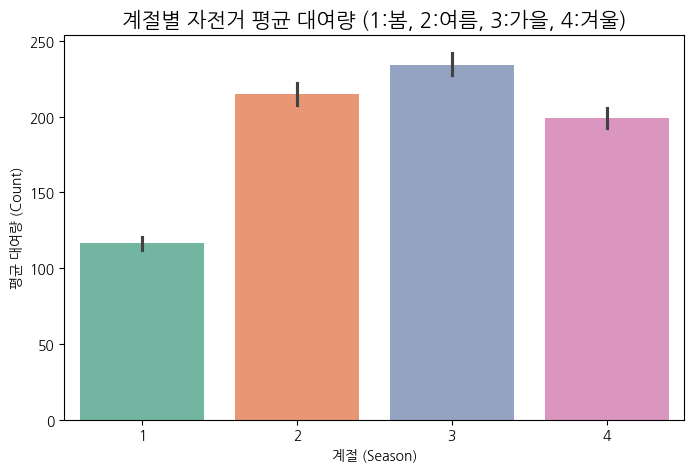

In [207]:
plt.figure(figsize=(8, 5))
sns.barplot(data=analize_df, x='season', y='count', palette='Set2', hue='season', legend=False)
plt.title('계절별 자전거 평균 대여량 (1:봄, 2:여름, 3:가을, 4:겨울)', fontsize=15)
plt.xlabel('계절 (Season)')
plt.ylabel('평균 대여량 (Count)')
plt.show()

### 4) 주말과 평일의 자전거 대여 수요 차이
주말과 평일 간의 '시간대별 패턴'을 함께 그래프로 표기하여 차이점을 확인합니다.

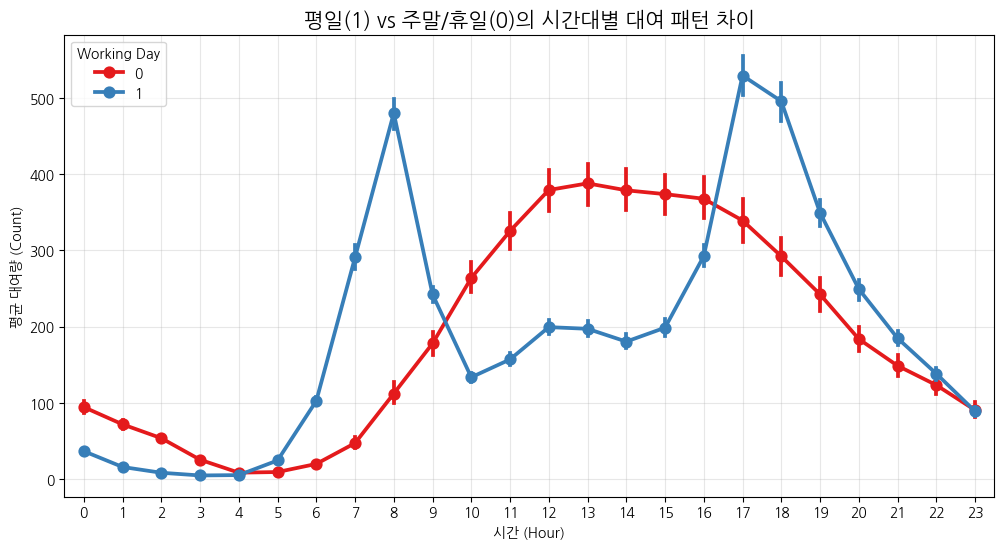

In [208]:
plt.figure(figsize=(12, 6))
# workingday: 1(평일), 0(주말 및 휴일)
sns.pointplot(data=analize_df, x='hour', y='count', hue='workingday', palette='Set1')
plt.title('평일(1) vs 주말/휴일(0)의 시간대별 대여 패턴 차이', fontsize=15)
plt.xlabel('시간 (Hour)')
plt.ylabel('평균 대여량 (Count)')
plt.legend(title='Working Day', loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

## 3. 데이터 전처리 계획

train_df, test_df 의 데이터가 어떤 구성을 가지고 있는지 분석하고, 전처리 계획을 수립합니다.

### 1) train_df 의 전체 데이터 히스토그램 출력 및 분석

모델 훈련에 사용될 train_df 의 데이터를 각 컬럼 별로 살펴  
분류값, 이상치, 스케일링 처리에 대한 필요를 정리합니다.  

#### 우선, 각 컬럼 별 히스토그램을 출력시켜봅니다

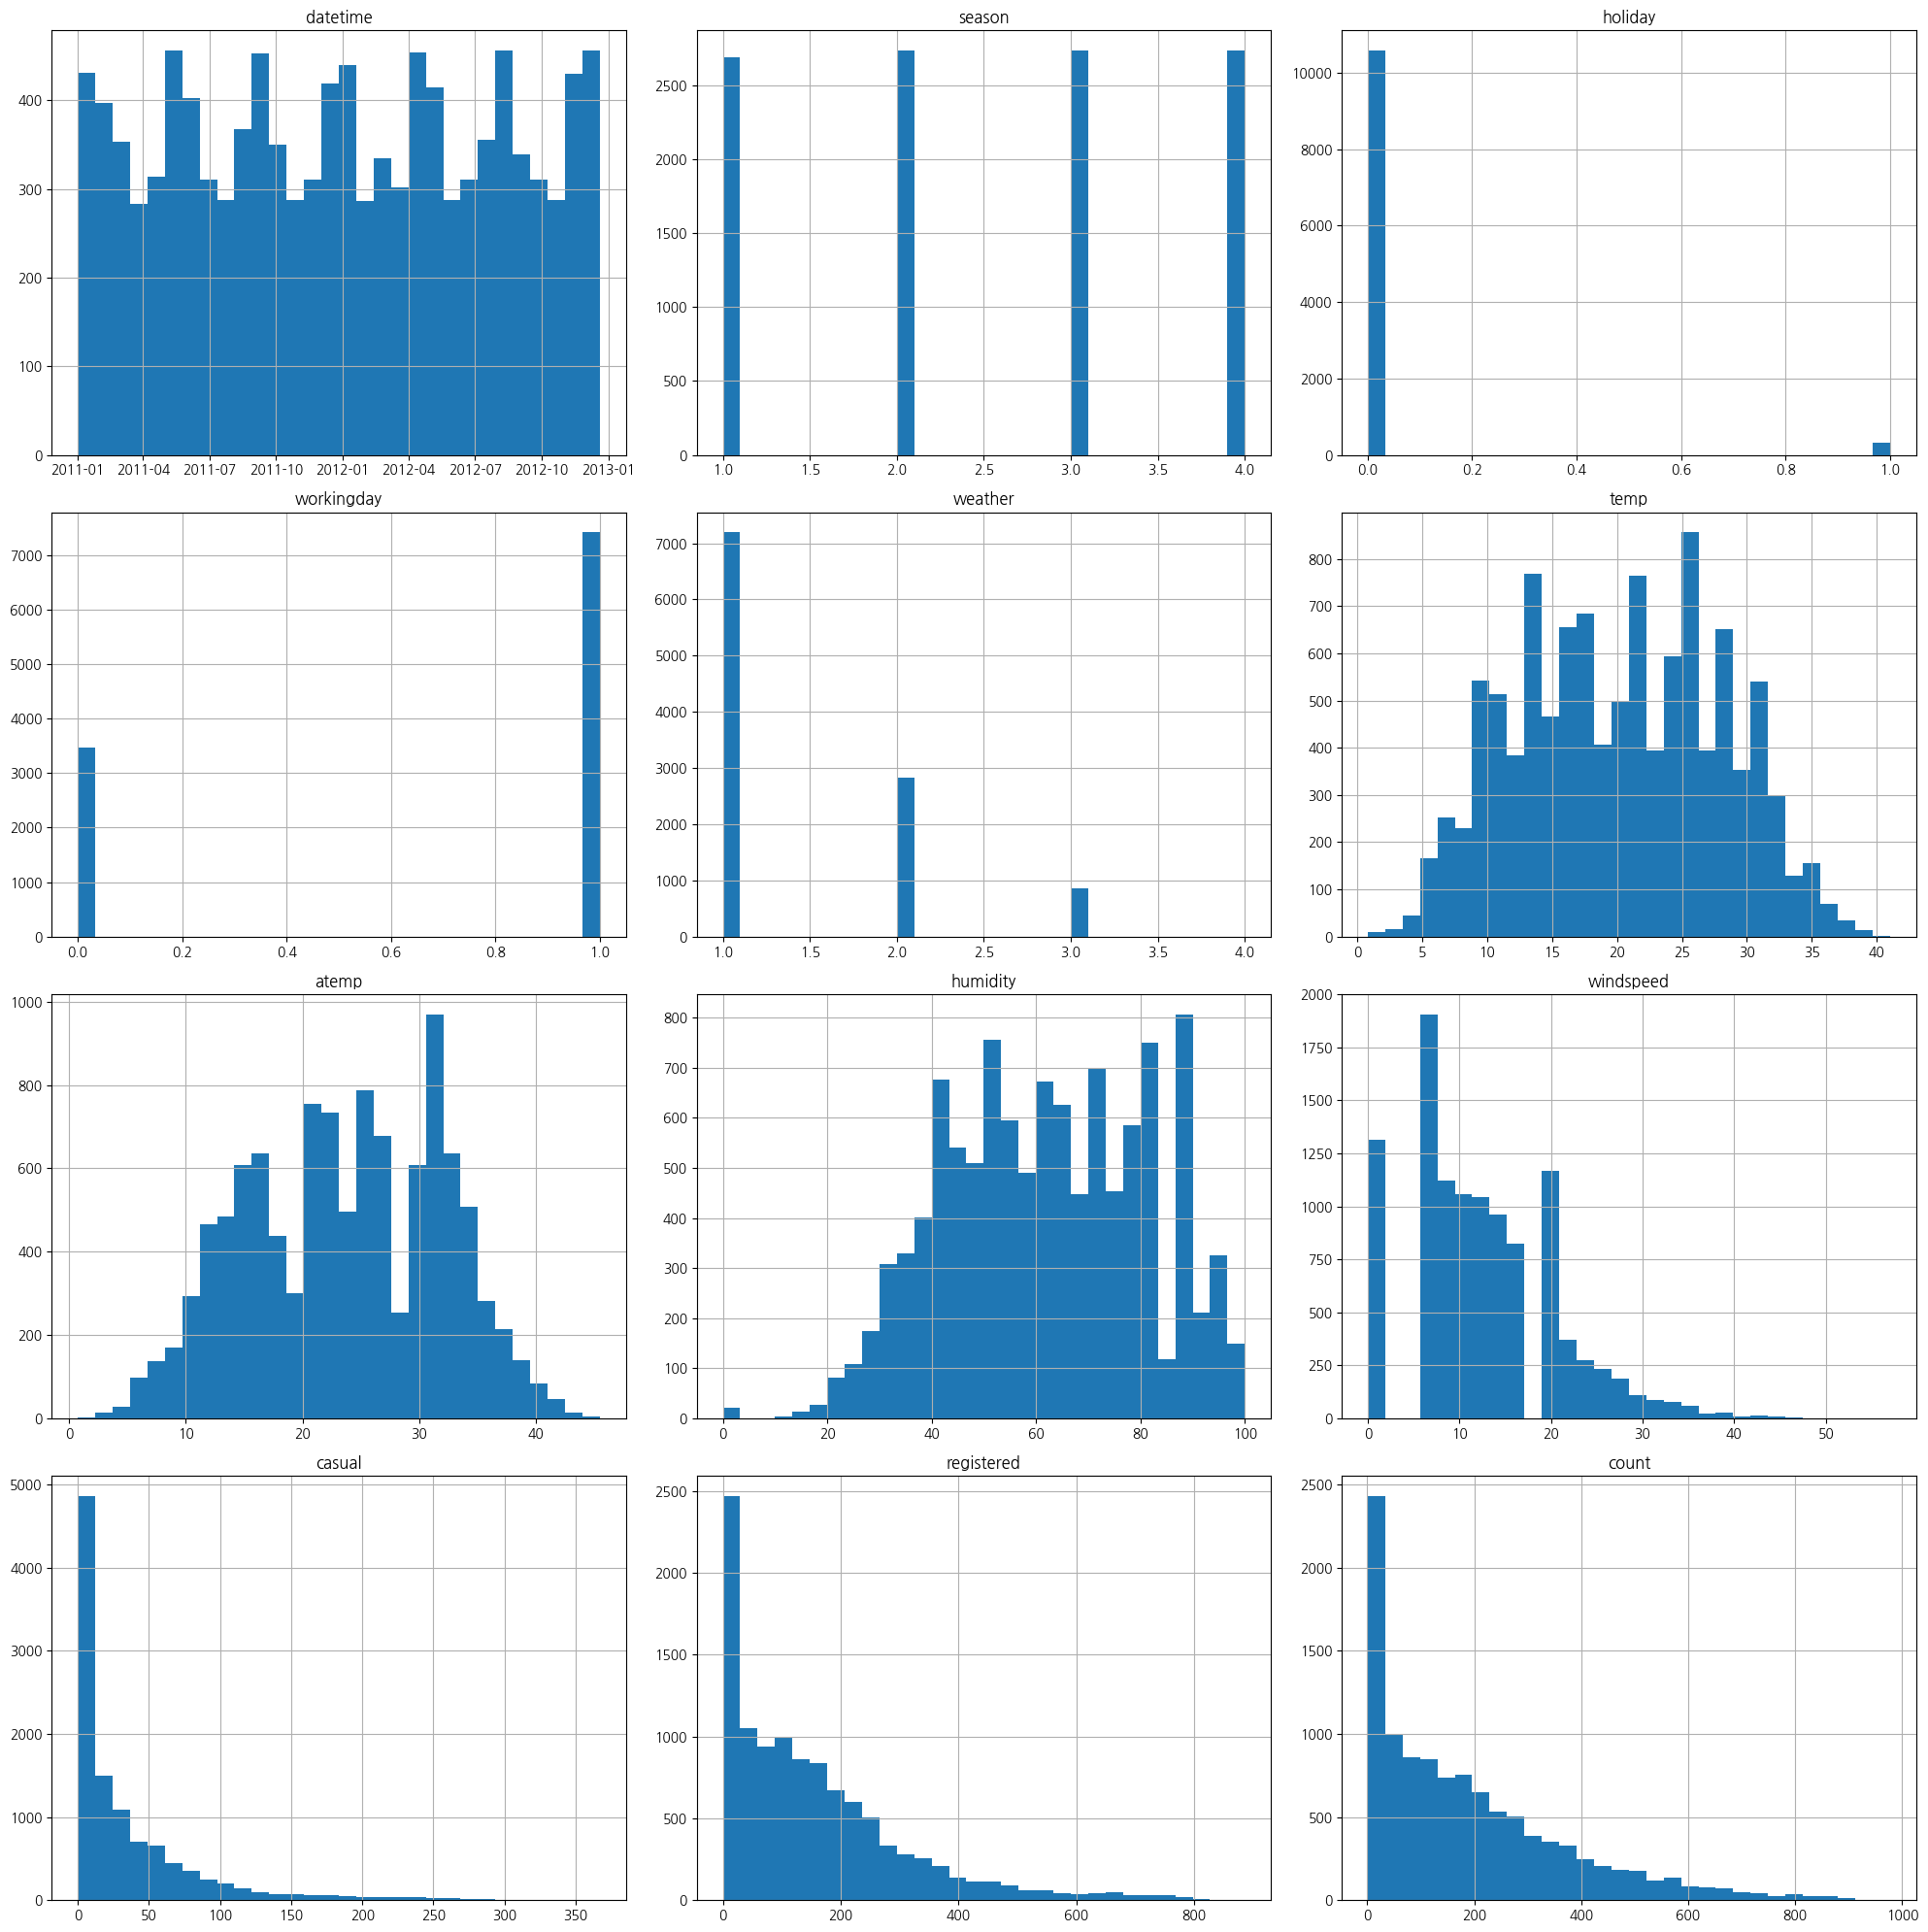

In [209]:
train_df.hist(bins=30, figsize=(20,20))
plt.tight_layout()
plt.show()

- datetime : 자전거 대여 날짜. 3개월 간격으로 대여수량이 400 ~ 300을 오가는 주기를 보입니다.
- season : 계절. 계절에 관계없이 고른 데이터 분포를 보입니다. One-Hot Encoding 분류 대상입니다.
- holiday : 휴일 여부. 휴일이 평일보다 압도적으로 작습니다. One-Hot Encoding 분류 대상입니다.
- workingday : 근무일 여부. 휴일 여부와 반대로 공휴일에도 자전거 대여 근무 여부를 표기합니다.  
    휴일에도 일하는 빈도가 높아, 평일의 절반에 근접합니다. One-Hot Encoding 분류 대상입니다.  
    holiday 컬럼과는 별도로 분류하여 취급해야 하는 값으로 판단합니다.
- weather : 날씨. 대부분 맑은 날씨며 악천후인 경우는 드뭅니다. One-Hot Encoding 분류 대상입니다.
- temp : 실측 섭씨 온도. 고른 데이터 분포를 보이고 있습니다.
- atemp : 체감 섭씨 온도. 고른 데이터 분포를 보이고 있습니다.  
    실제 기온과는 달리 19도와 28도 쯤에서 체감 온도가 줄어드는 현상이 관찰됩니다.
- humidity : 습도(%). 좋은 분포를 보이나, 85% 근처에서 데이터 밀도가 급격히 낮아지는 현상이 관찰됩니다.
- windspeed : 풍속(m/s). 바람이 아예 불지 않는 상황을 제외하면  
    5m/s 이하의 풍속은 데이터가 없는 이상 현상이 관찰됩니다.  
    또한 18 ~ 19m/s 구간에서도 데이터가 없는 이상 현상이 관찰됩니다.  
    위는 결측 구간으로 판단됩니다 [(근거, 논문의 fig 1)](https://www.sciencedirect.com/science/article/pii/S0960148126001059)
- casual : 등록되지 않은 사용자의 대여 수. 1 ~ 10회 정도 빌리는 사람이 다수로 관찰됩니다.
- registered : 등록된 사용자의 대여 수. 역시 casual 컬럼과 동일한 분포를 보입니다.
- count : 실제 대여 수. casual, registered 컬럼의 합으로 보이며, 둘과 같은 분포를 보입니다.

#### <중간 정리>
- One-Hot Encoding 분류가 필요한 컬럼 : season, holiday, workingday, weather
- 측정 이상치 조치 필요 : humidity, windspeed
- 대여 횟수 0인 상황 체크 : casual, registered, count

#### 이제, train_df 의 히트맵을 그려 각 컬럼 간 연관 관계를 살핍니다.

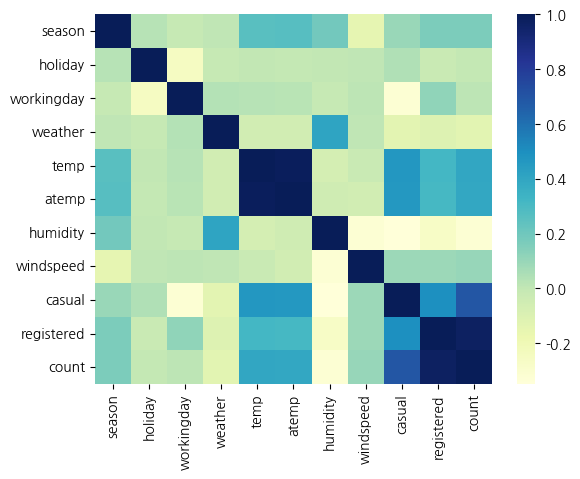

In [210]:
seq = train_df.select_dtypes(include='number')
corr = seq.corr(method='pearson')
sns.heatmap(corr, cmap='YlGnBu')
plt.show()

- temp와 atemp 가 아주 강한 상관관계를 보입니다. temp 하나만 남기는 것이 적절해 보입니다.
- casual과 registered의 합산이 count로 보이는데, 이러한 관계 때문에 세 컬럼이 강한 상관 관계를 보입니다.  
    이것을 적절히 가공할 방법을 모색해야 합니다.

#### <데이터 전처리 필요 항목 정리>
- datetime 을 유의미한 시간 특성을 추출하여 정리합니다.
- season, holiday, workingday, weather는 보다 나은 성능을 위해 One-Hot Encoding 처리합니다.
- humidity 와 windspeed 의 측정 이상은 temp, weather, season 컬럼을 근거로 랜덤포레스트 기법[^1]을 적용한 보간법으로 처리합니다.
- casual, registered, count의 경우에는 대여 횟수가 0인 이상치를 찾은 후  
    강한 상관 관계를 보이는 컬럼 간에 보이는 **완전 공선성 문제**를 해결하기 위해  
    casual, registered 컬럼은 삭제 처리합니다.
- temp와 atemp 가 아주 강한 상관관계를 보여 다중공선성 방지를 위해 atemp 컬럼을 삭제처리합니다.

[^1]: 여러 개의 **결정 트리(Decision Tree)**를 무작위성(randomness)을 도입해 학습시킨 뒤,  
그 결과를 **집계(aggregation)**하여 예측하는 앙상블 학습(Ensemble Learning) 기법.

### 2) test_df 의 전체 데이터 히스토그램 출력 및 분석

모델 훈련에 사용될 test_df 의 데이터를 각 컬럼 별로 살펴,
분류값, 이상치, 스케일링 처리에 대한 필요를 정리합니다.  

#### 우선, 각 컬럼 별 히스토그램을 출력시켜봅니다

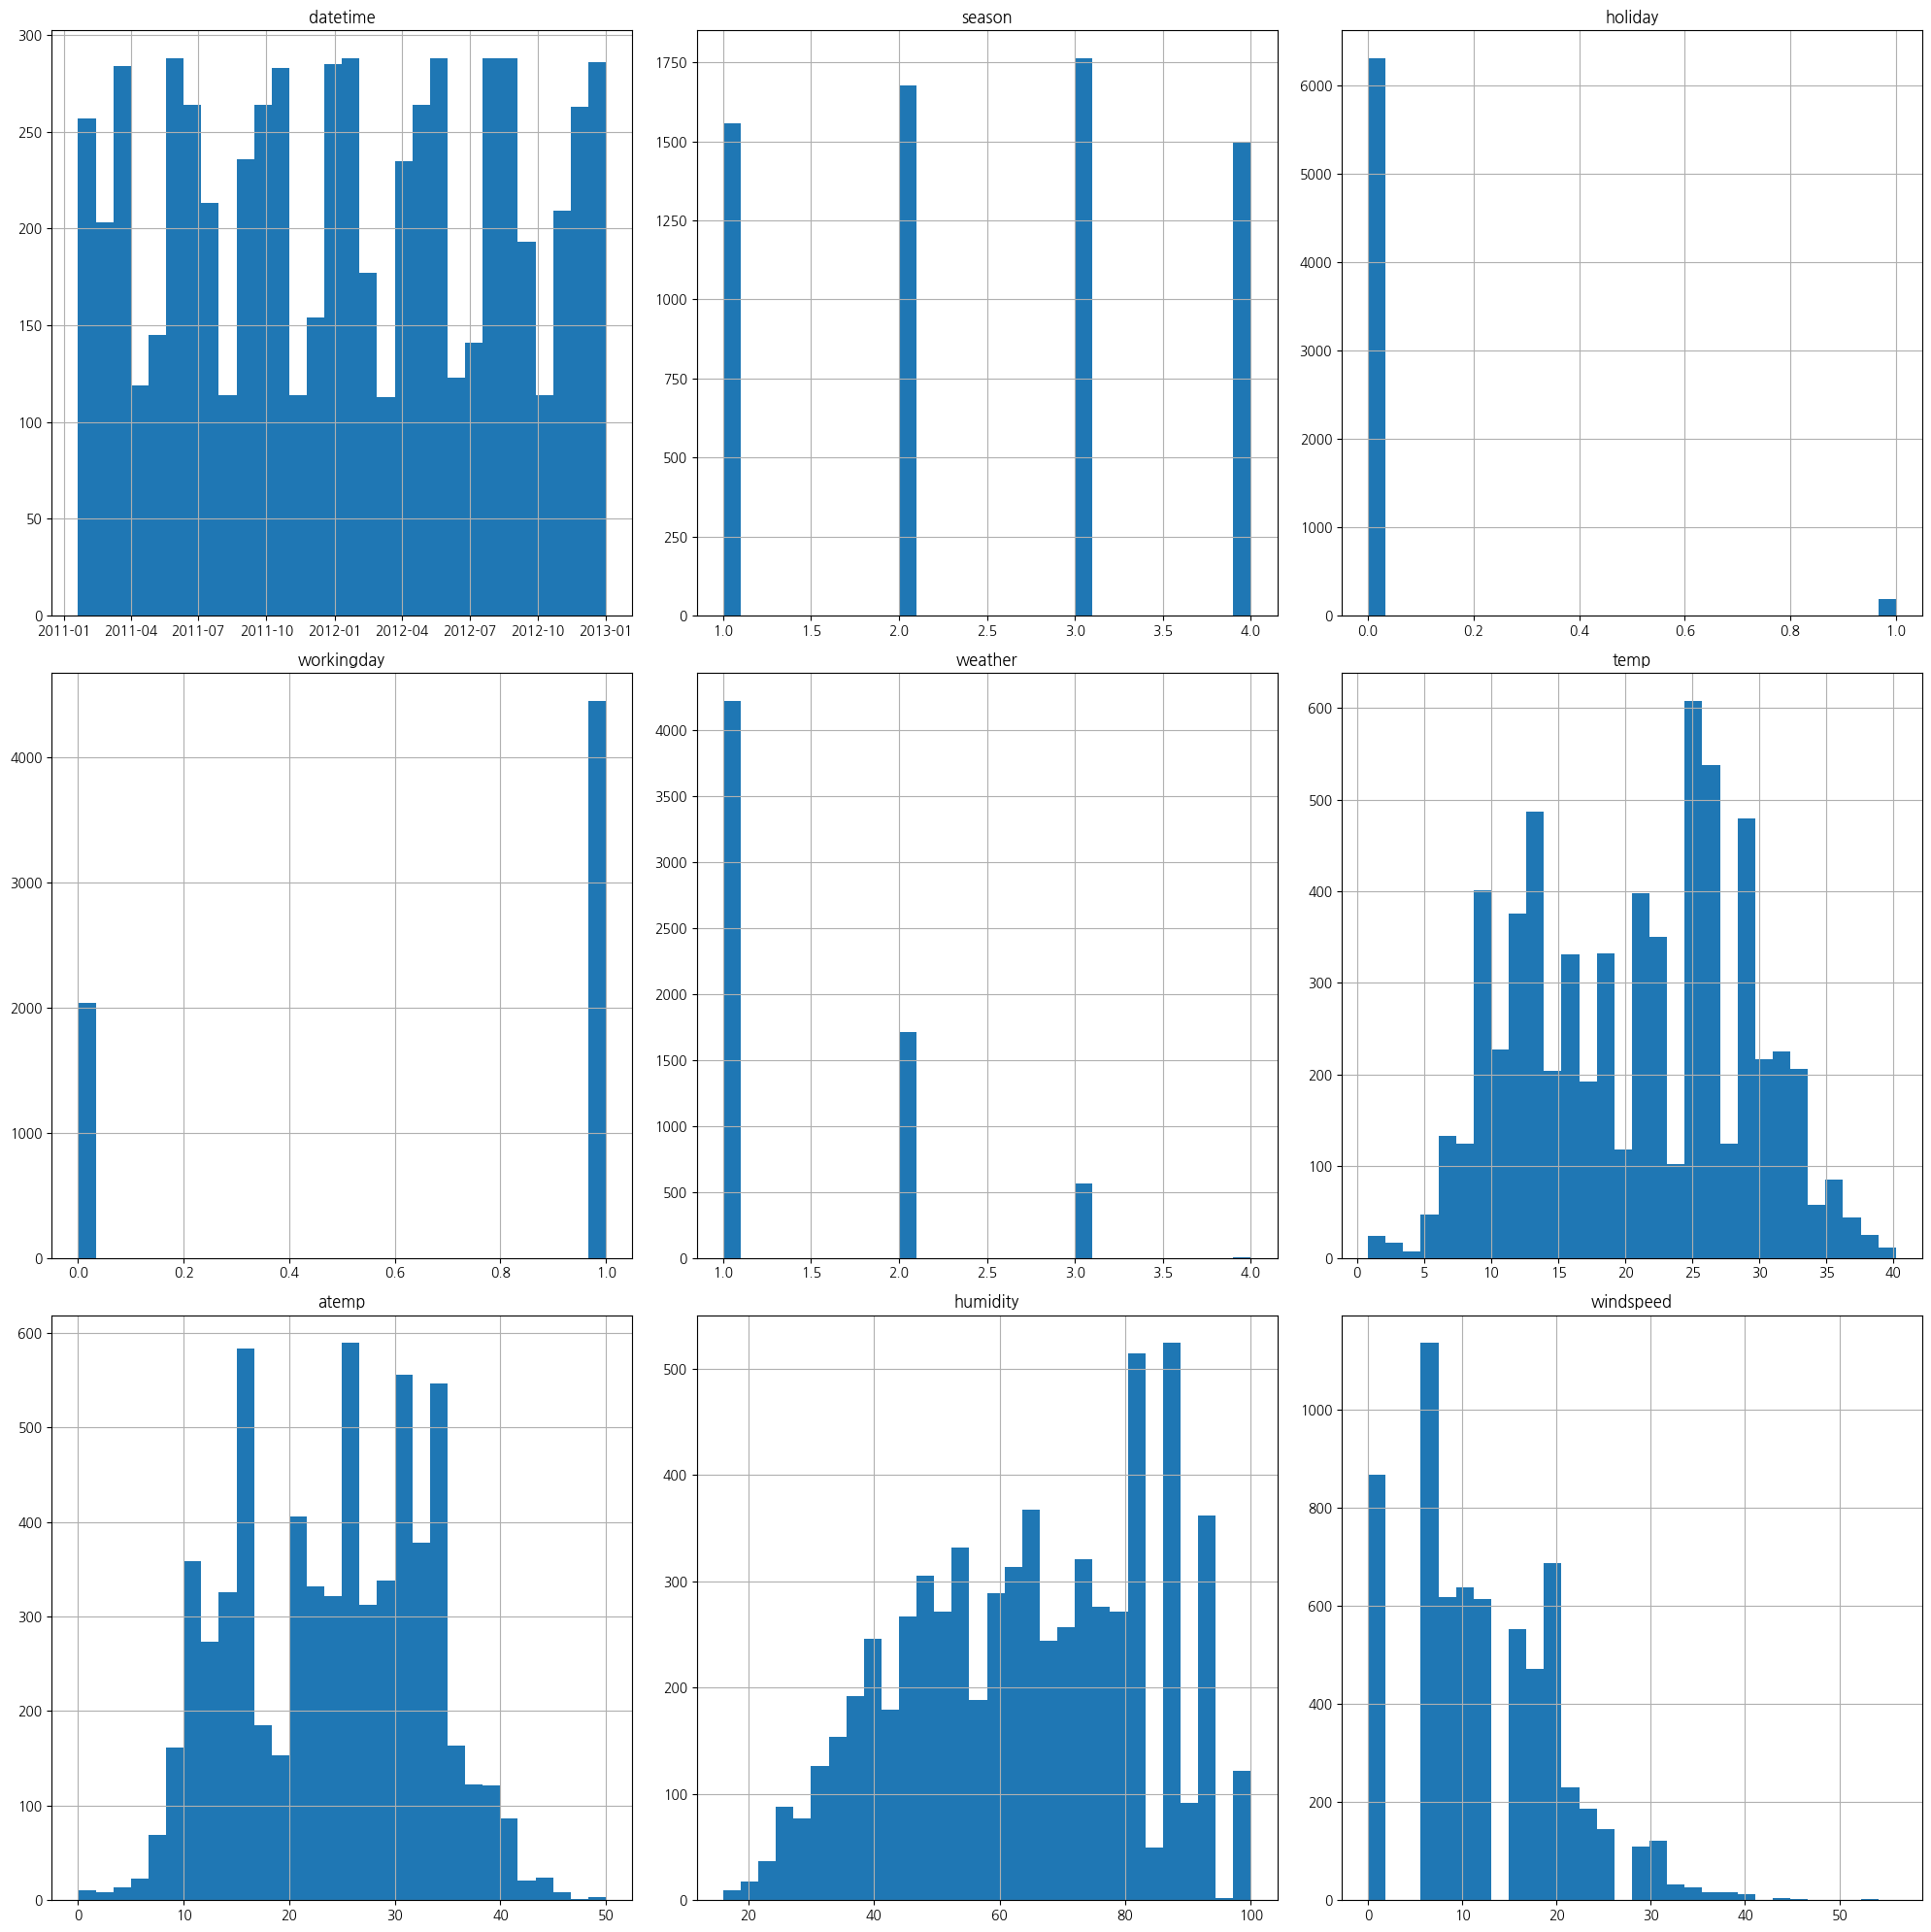

In [211]:
test_df.hist(bins=30, figsize=(20,20))
plt.tight_layout()
plt.show()

- datetime : 자전거 대여 날짜. 3개월 간격으로 대여수량이 300 ~ 150을 오가는 주기를 보입니다.
- season : 계절. 계절에 관계없이 고른 데이터 분포를 보입니다. One-Hot Encoding 분류 대상입니다.
- holiday : 휴일 여부. 휴일이 평일보다 압도적으로 작습니다. One-Hot Encoding 분류 대상입니다.
- workingday : 근무일 여부. 휴일 여부와 반대로 공휴일에도 자전거 대여 근무 여부를 표기합니다.  
    휴일에도 일하는 빈도가 높아, 평일의 절반에 근접합니다. One-Hot Encoding 분류 대상입니다.  
    holiday 컬럼과는 별도로 분류하여 취급해야 하는 값으로 판단합니다.
- weather : 날씨. 대부분 맑은 날씨며 악천후인 경우는 드뭅니다. One-Hot Encoding 분류 대상입니다.
- temp : 실측 섭씨 온도. 고른 데이터 분포를 보이고 있습니다.
- atemp : 체감 섭씨 온도. 고른 데이터 분포를 보이고 있습니다.  
    19도 쯤에서 체감 온도가 줄어드는 현상이 관찰됩니다.
- humidity : 습도(%). 좋은 분포를 보이나, 85% 근처에서 데이터 밀도가 급격히 낮아지는 현상이 관찰됩니다.
- windspeed : 풍속(m/s). 바람이 아예 불지 않는 상황을 제외하면  
    5m/s 이하의 풍속은 데이터가 없는 이상 현상이 관찰됩니다.  
    또한 14 ~ 15m/s, 18 ~ 19m/s 구간에서도 데이터가 없는 이상 현상이 관찰됩니다.  
    [(근거, 논문의 fig 1)](https://www.sciencedirect.com/science/article/pii/S0960148126001059)

#### <중간 정리>
- One-Hot Encoding 분류가 필요한 컬럼 : season, holiday, workingday, weather
- 측정 이상치 조치 필요 : humidity, windspeed

#### 이제, test_df 의 히트맵을 그려 각 컬럼 간 연관 관계를 살핍니다.

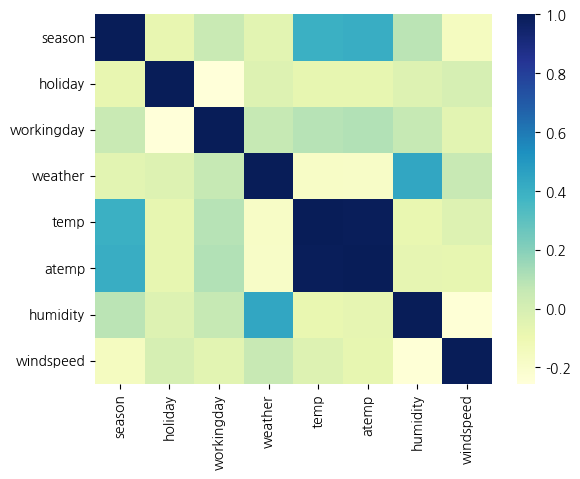

In [212]:
seq = test_df.select_dtypes(include='number')
corr = seq.corr(method='pearson')
sns.heatmap(corr, cmap='YlGnBu')
plt.show()

- temp와 atemp 가 아주 강한 상관관계를 보입니다. temp 하나만 남기는 것이 적절해 보입니다.

#### <데이터 전처리 필요 항목 정리>
- datetime 을 유의미한 시간 특성을 추출하여 정리합니다.
- season, holiday, workingday, weather는 보다 나은 성능을 위해 One-Hot Encoding 처리합니다.
- humidity 와 windspeed 의 측정 이상은 temp, weather, season 컬럼을 근거로 랜덤포레스트 기법을 적용한 보간법으로 처리합니다.
- temp와 atemp 가 아주 강한 상관관계를 보이며 다중공선성 방지를 위해 atemp 컬럼을 삭제처리합니다.

## 4. 데이터 전처리 실행

데이터 분석 과정에서 얻어진 데이터 전처리 항목들을 수행하여  
머신러닝이 보다 효과적으로 작동할 수 있도록 데이터를 다듬습니다.  

train_df 와 test_df 에게 수행할 공통 전처리 사항은 다음과 같습니다.
- datetime 에서 유의미한 시간 특성을 추출하여 정리합니다.
- season, holiday, workingday, weather 는 보다 나은 성능을 위해 One-Hot Encoding 처리합니다.
- humidity 와 windspeed 의 측정 이상은 temp, weather, season 컬럼을 근거로 랜덤포레스트 기법을 적용한 보간법으로 처리합니다.
- temp와 atemp 가 아주 강한 상관관계를 보여 다중공선성 방지를 위해 atemp 컬럼을 삭제처리합니다.
- 분류형이 아닌 모든 수치형 데이터에 스케일링을 적용합니다.

train_df 에만 적용해야 하는 전처리 사항은 다음과 같습니다.
- casual, registered, count 의 경우에는 대여 횟수가 0인 이상치를 찾은 후  
    강한 상관 관계를 보이는 컬럼 간에 보이는 **완전 공선성 문제**를 해결하기 위해서  
    casual, registered 컬럼은 삭제 처리합니다.
- 랜덤포레스트 기법을 적용한 보간법으로 처리할 때 해당 모델을 저장하여 test_df 에서도 같은 모델을 적용 할 수 있도록 합니다.
- 스케일러를 적용하고 저장하여 test_df 에게도 같은 스케일러를 적용할 수 있도록 합니다.
- count 값은 스케일링 하지 않습니다.

test_df 에만 적용해야 하는 전처리 사항은 다음과 같습니다.
- count 는 측정해야 하는 값이기 때문에 컬럼에 포함시키지 않습니다.
- 저장된 랜덤포레스트 모델을 사용하여 humidity 와 windspeed의 이상값을 보간합니다.
- train_df에서 사용했던 스케일러로 스케일링을 진행합니다.

우선 train_df 에서 count 가 0 이하인 상황이 있는지 확인합니다.

In [213]:
print((train_df['count'] <= 0).sum())

0


0이 없는 것이 확인되므로, 이제 전처리를 진행합니다.

### 1) 전처리 클래스 구현
아래는 전처리 기능을 구현한 클레스입니다.

In [214]:
class DataFramePreprocessor:
    def __init__(self):
        # 학습 상태를 기억할 변수 생성
        self.rf_models = {}  # 0값 보간을 위한 랜덤 포레스트 모델 저장소
        self.scaler = MinMaxScaler() # 스케일러 인스턴스
        self.expected_cols = None # 원핫인코딩 후의 정확한 컬럼 리스트
        
        # 설정값
        self.datetime_features = ['year', 'month', 'hour', 'dayofweek']
        self.one_hot_cols = ['dayofweek', 'season', 'holiday', 'workingday', 'weather']
        self.impute_features = ['temp', 'season_1', 'season_2', 'season_3', 'season_4', 
                                'weather_1', 'weather_2', 'weather_3', 'weather_4']

    def _extract_datetime_features(self, df):
        # 유의미한 시간 특성 추출
        df['year'] = df['datetime'].dt.year # datetime_features[0]
        df['month'] = df['datetime'].dt.month # datetime_features[1]
        df['hour'] = df['datetime'].dt.hour # datetime_features[2]
        df['dayofweek'] = df['datetime'].dt.dayofweek # datetime_features[3], 0:월요일 ~ 6:일요일
        
        df = df.drop(columns=['datetime'])
        
        return df

    def _impute_target(self, df, target_col, is_train):
        """내부 보간 로직: is_train 여부에 따라 학습/예측 또는 예측만 수행"""
        predict_data = df[df[target_col] == 0]
        if len(predict_data) == 0:
            return df
            
        if is_train:
            # 훈련 데이터: 0이 아닌 데이터로 모델을 학습(fit)하고 저장
            train_data = df[df[target_col] != 0]
            rf_model = RandomForestRegressor(random_state=42)
            rf_model.fit(train_data[self.impute_features], train_data[target_col])
            self.rf_models[target_col] = rf_model # 모델 기억하기
            
            df.loc[df[target_col] == 0, target_col] = rf_model.predict(predict_data[self.impute_features])
        else:
            # 테스트 데이터: train에서 기억해둔 모델을 꺼내서 예측만 수행
            saved_model = self.rf_models[target_col]
            df.loc[df[target_col] == 0, target_col] = saved_model.predict(predict_data[self.impute_features])
            
        return df

    def preprocess_train(self, target_df):
        # 원본 보존 처리
        df = target_df.copy()
        
        # datetime 특성 추출
        df = self._extract_datetime_features(df)
        
        # atemp, casual,registered 컬럼 제거
        df = df.drop(columns=['atemp', 'casual', 'registered'], errors='ignore')

        # one-hot encoding 실행
        df = pd.get_dummies(df, columns=self.one_hot_cols, dtype=int)
        self.expected_cols = [col for col in df.columns if col != 'count'] # 원핫인코딩 후의 컬럼 리스트 기억하기
        
        # humidity와 windspeed 컬럼의 비어있는 구간 보간
        df['humidity'] = df['humidity'].astype(float)
        df = self._impute_target(df, target_col='humidity', is_train=True)
        df['humidity'] = df['humidity'].astype(int)
        
        df['windspeed'] = df['windspeed'].astype(float)
        df = self._impute_target(df, target_col='windspeed', is_train=True)
        
        # 스케일링 실행
        # 카테고리성 범주 및 정답(count), 날짜 컬럼 제외
        exclude_cols = self.datetime_features + ['count'] + [c for c in df.columns if c.startswith(tuple(self.one_hot_cols))]
        self.scale_cols = [col for col in df.columns if col not in exclude_cols]
        
        df[self.scale_cols] = self.scaler.fit_transform(df[self.scale_cols]) # fit & transform
        
        return df
    
    def preprocess_test(self, target_df):
        # 원본 보존 처리
        df = target_df.copy()
        
        # datetime 특성 추출
        df = self._extract_datetime_features(df)
        
        # atemp 컬럼 제거
        df = df.drop(columns=['atemp'], errors='ignore')

        # one-hot encoding 실행 (train에서 기억한 컬럼과 일치하도록)
        df = pd.get_dummies(df, columns=self.one_hot_cols, dtype=int)
        # 훈련 데이터엔 있었으나 테스트엔 없는 컬럼은 0으로 생성, 불필요한 건 제거
        df = df.reindex(columns=self.expected_cols, fill_value=0)
        
        # humidity와 windspeed 컬럼의 비어있는 구간 보간
        df['humidity'] = df['humidity'].astype(float)
        df = self._impute_target(df, target_col='humidity', is_train=False)
        df['humidity'] = df['humidity'].astype(int)
        
        df['windspeed'] = df['windspeed'].astype(float)
        df = self._impute_target(df, target_col='windspeed', is_train=False)
        
        # 스케일링 실행 (train에서 fit한 스케일러 사용)
        # 테스트셋에는 'count' 컬럼이 없으므로 존재하는 컬럼만 스케일링
        scale_cols_exist = [c for c in self.scale_cols if c in df.columns]
        df[scale_cols_exist] = self.scaler.transform(df[scale_cols_exist]) # transform만
        
        return df

이제 전처리 준비가 끝났기 때문에, train_df 와 test_df 에 전처리를 적용하고,  
잘 적용되었는지 확인을 진행합니다.

### 2) train_df 와 test_df 의 전처리 진행

In [215]:
df_preprocessor = DataFramePreprocessor()

processed_train_df = df_preprocessor.preprocess_train(train_df)
processed_test_df = df_preprocessor.preprocess_test(test_df)

### 3) processed_train_df 의 전체 데이터 히스토그램 출력 및 분석

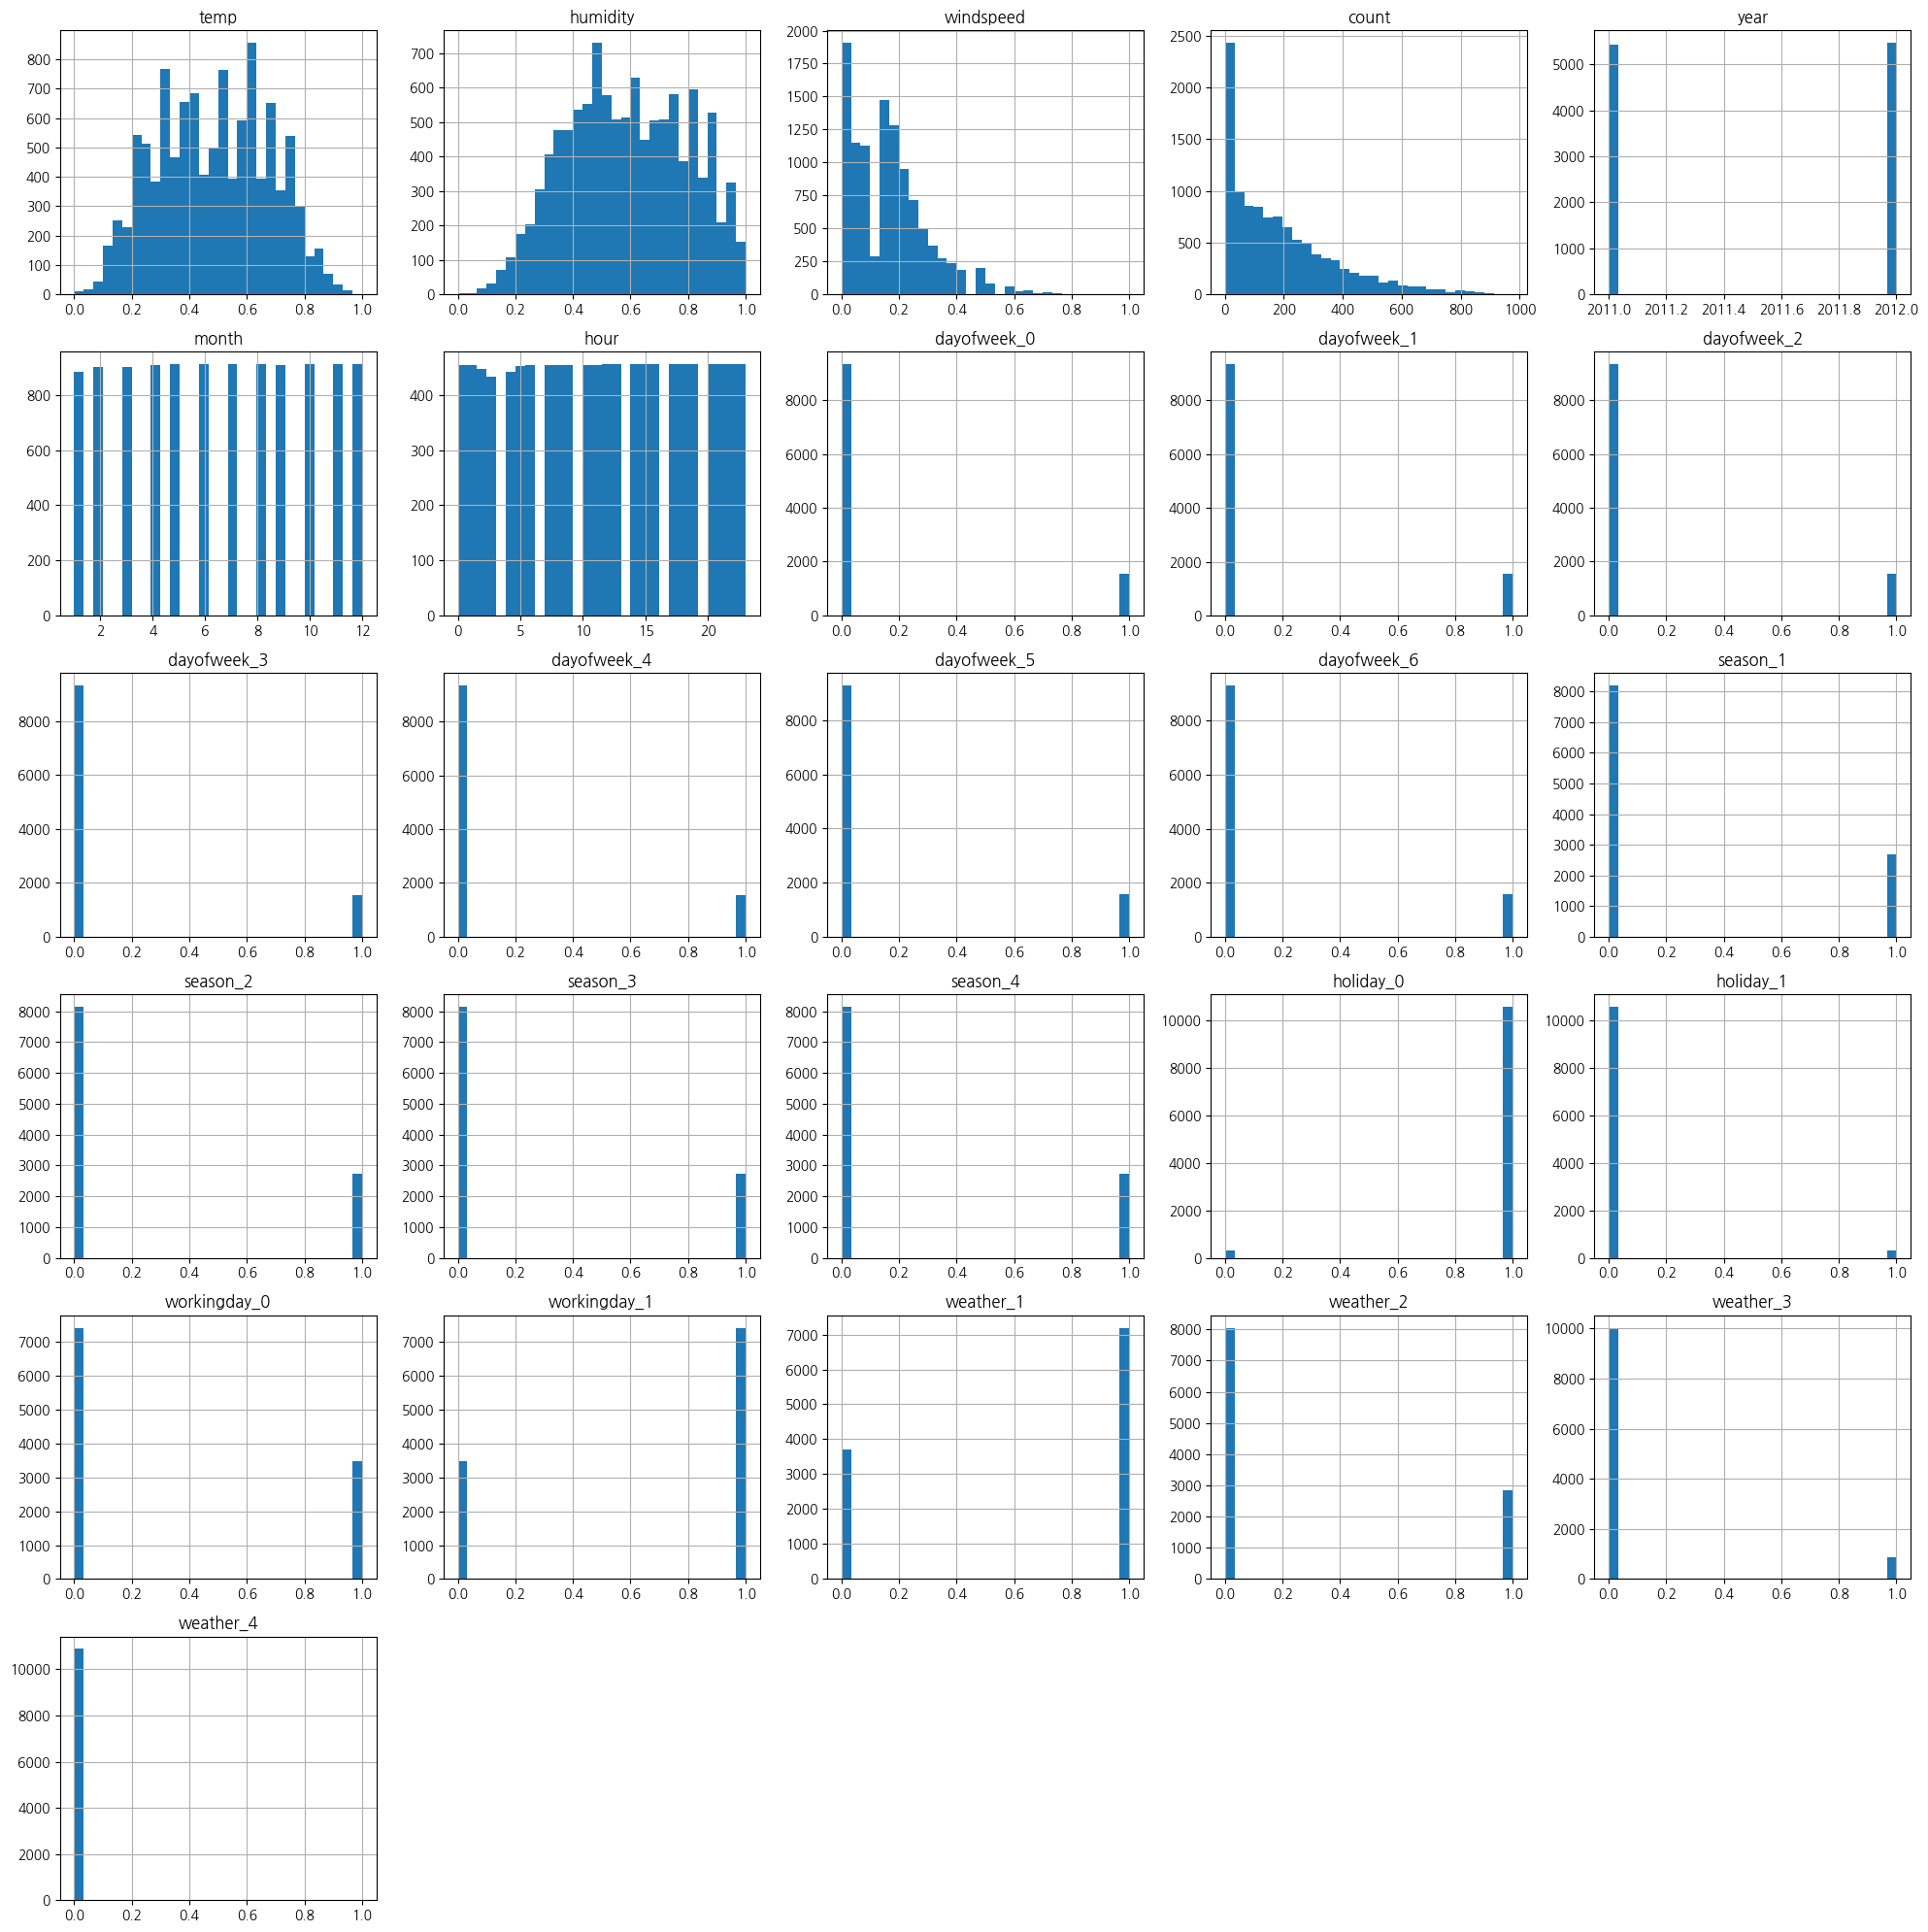

In [216]:
processed_train_df.hist(bins=30, figsize=(20,20))
plt.tight_layout()
plt.show()

train_df 가 전처리가 잘 수행된 형태인 processed_train_df 로 변했음을 확인 할 수 있습니다.  
특히 humidity, windspeed 의 경우는 값 자체의 낙차를 없애지는 못했어도  
전반적인 그래프의 분포가 채워졌음을 확인 할 수 있습니다.

### 4) processed_test_df 의 전체 데이터 히스토그램 출력 및 분석

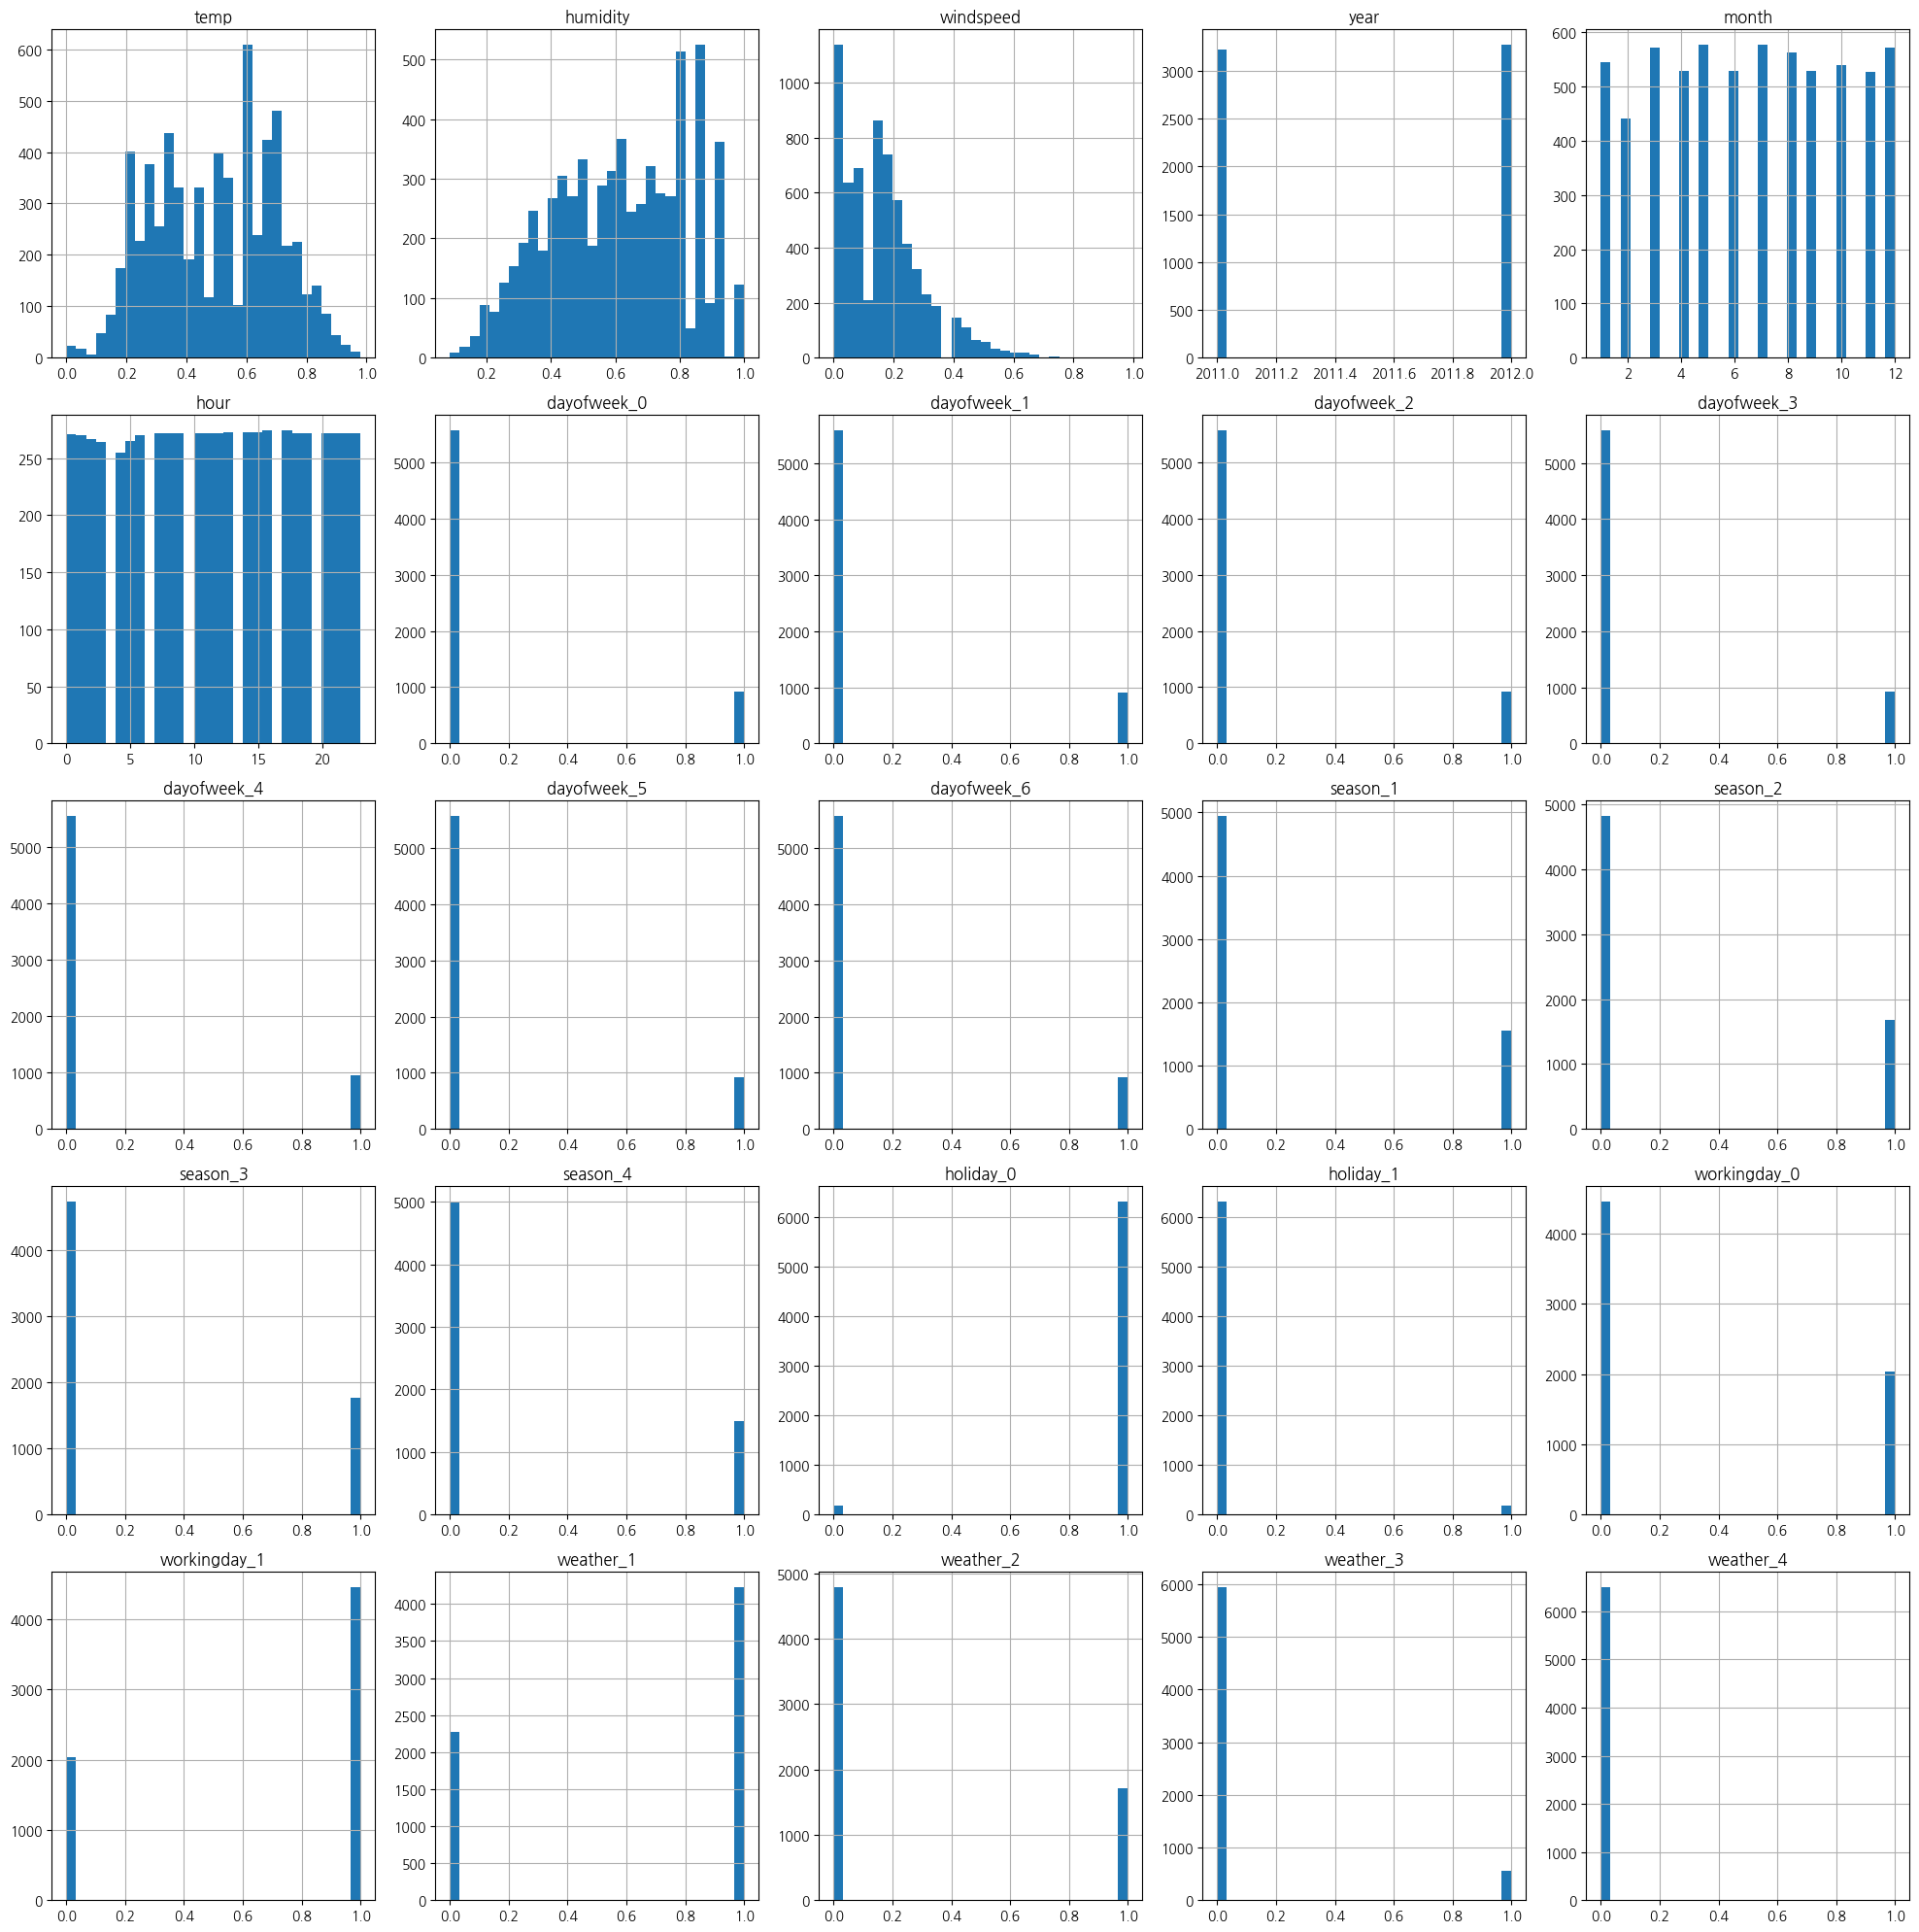

In [217]:
processed_test_df.hist(bins=30, figsize=(20,20))
plt.tight_layout()
plt.show()

processed_train_df 와 같은 꼴의 컬럼을 가지고 있으며,  
측정해야 할 count 컬럼도 추가되지 않았음을 확인 할 수 있습니다.

데이터 전처리는 끝났습니다. 이제 머신러닝 학습을 위한 데이터 세트를 구축합니다.

## 5. 학습 데이터 세트 구축
머신러닝의 학습을 위해서는 학습 데이터(x_train, x_test)와  
검증 데이터(y_train, y_test)를 기존의 processed_train_df 로부터 나눠서 적용해야 합니다.

In [218]:
x = processed_train_df.drop(columns=['count'])
y = processed_train_df['count']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

분할이 진행되었으므로 간단히 내용을 살펴 봅니다.

In [219]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(8708, 25)
(2178, 25)
(8708,)
(2178,)


분할 전 데이터의 크기가 10886 이므로, 잘 분할되었음을 확인할 수 있습니다.

드디어, 머신러닝을 돌려볼 때입니다.

## 6. 머신러닝 모델 선정 및 학습 진행
우리는 자전거 대여량을 되도록 정확하게 예측하는 것을 원합니다.  
자전거 대여량은 수치로 표현되는 회귀문제입니다.  
따라서 Lasso, Rigde, RandomForest, XGBoost, LightGBM 5종을 모델로 선정하고  
각각 가장 기본적인 설정으로 학습을 1차 진행하여 평가를 진행하도록 합니다.

### 1) 평가 함수 정의 및 구현

평가 함수로는 RMSLE(Root Mean Squared Logarithmic Error) 를 사용합니다.  
평균 제곱 로그 오차의 제곱근으로 부를 수 있을 것 같습니다.  
예측 값과 실제 값의 차이를 로그 변환하여 계산한 후, 그 차이의 제곱 평균의 제곱근을 구한 값입니다.
$$
\text{RMSLE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} \left( \log(1 + \hat{y}_i) - \log(1 + y_i) \right)^2}
$$
공식은 위와 같으며, 이것을 구현한 함수는 아래와 같습니다.

In [220]:
def evaluate_model_rmsle(target_test, target_predict):
    target_predict = np.maximum(target_predict, 0)  # 음수 예측값 방지
    log_test = np.log1p(target_test)
    log_predict = np.log1p(target_predict)
    rmsle = np.sqrt(mean_squared_error(log_test, log_predict))
    return rmsle

### 2) 머신러닝 모델 선언 및 기본 하이퍼파라미터 적용

In [221]:
# 사용할 모델 임포트
from sklearn.linear_model import Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# 각 모델 객체를 기본 하이퍼파라메터로 생성 및 딕셔너리에 담기
models = {
    "Lasso": Lasso(random_state=42),
    "Ridge": Ridge(random_state=42),
    "RandomForest": RandomForestRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42),
    "LightGBM": LGBMRegressor(random_state=42, verbose=-1) # verbose=-1은 불필요한 로그 숨김
}

이제 평가함수와 머신러닝 모델 선언이 끝났습니다.  
본격적으로 모델별 학습을 진행하고 RMSLE 점수를 통해 성능을 측정합니다.

## 7. 머신러닝 모델 1차 학습 및 분석 : 기본 값 확인

In [222]:
# 모델 별 학습 및 평가 진행
print("--- 베이스라인 모델 성능 1차 평가 결과 ---")

for model_name, model in models.items():
    # 학습 데이터로 공부(학습)
    model.fit(x_train, y_train)
    
    # 검증 데이터로 시험(예측)
    target_predict = model.predict(x_test)
    
    # 성적표 채점
    rmsle = evaluate_model_rmsle(y_test, target_predict)
    
    # 결과 출력
    print(f"[{model_name}]")
    print(f"  - RMSLE: {rmsle:.2f} (평균 제곱 로그 오차의 제곱근)")
    print("-" * 50)

--- 베이스라인 모델 성능 1차 평가 결과 ---
[Lasso]
  - RMSLE: 1.27 (평균 제곱 로그 오차의 제곱근)
--------------------------------------------------
[Ridge]
  - RMSLE: 1.31 (평균 제곱 로그 오차의 제곱근)
--------------------------------------------------
[RandomForest]
  - RMSLE: 0.33 (평균 제곱 로그 오차의 제곱근)
--------------------------------------------------
[XGBoost]
  - RMSLE: 0.48 (평균 제곱 로그 오차의 제곱근)
--------------------------------------------------
[LightGBM]
  - RMSLE: 0.44 (평균 제곱 로그 오차의 제곱근)
--------------------------------------------------


- Lasso, Ridge 모델은 낮은 점수가 출력되었습니다.  
    기본 상태인 선형 모델로 다양한 패턴을 예측하여 더 그런 면이 있는 것으로 보입니다만,  
    결정트리방식인 나머지 셋과 비교했을 때 다항 특성을 추가하더라도  
    점수 격차를 따라잡기는 힘들 것으로 보입니다.

- 앙상블 모델인 XGBoost, LightGBM을 제치고 RandomForest 가 1위를 차지했습니다.  
    여러 평가 결과를 평균내는 방식이라 예측값이 고르게 분포하고,  
    이것은 RMSLE의 평가 방식에 최적화되어 있는 값이기 때문일 것이라 생각합니다.

- 앙상블 모델인 XGBoost, LightGBM은 위에서 설명한 RandomForset 보다 낮은 성능을 보였습니다.  
    이 앙상블 모델들은 MSE(오차 제곱)을 줄이는 방향으로 특화되어 있다 합니다.  
    그래서 분석 도중 값이 분포가 작은 곳에서  
    RMSLE가 패널티를 부과하는 0에 가까운 값을 반환한 빈도가 높을 것으로 보입니다.

## 8. 머신러닝 모델 2차 학습 및 분석 : 타겟에 로그 변환 적용

위에서 얻어진 결과는 별도의 라이브러리까지 설치해야 하는 앙상블 모델이  
앙상블 모델들의 기반 모델이라 할 수 있는 RandomForest에 밀리는 납득하기 어려운 결과를 보입니다.  

따라서 RMSLE에 최적화된 데이터로 훈련을 진행 할 수 있게 한다면  
앙상블 모델의 결과를 좀 더 좋게 만들 수 있을 것으로 파악됩니다.

In [223]:
# 모델 별 학습 및 평가 진행 (타겟 로그 변환 적용) 
print("--- 베이스라인 모델 성능 2차 평가 결과 ---")

for model_name, model in models.items():
    # 정답지(y_train)를 로그로 변환하여 숫자를 작게 만듬
    log_y_train = np.log1p(y_train)
    
    # 변환된 정답지(log_y_train)로 학습을 진행
    model.fit(x_train, log_y_train)
    
    log_predict = model.predict(x_test)
    
    # 원래 자전거 대여량 단위로 복원
    target_predict = np.expm1(log_predict)
    
    rmsle = evaluate_model_rmsle(y_test, target_predict)
    
    print(f"[{model_name}]")
    print(f"  - RMSLE: {rmsle:.4f} (평균 제곱 로그 오차의 제곱근)")
    print("-" * 50)

--- 베이스라인 모델 성능 2차 평가 결과 ---
[Lasso]
  - RMSLE: 1.1877 (평균 제곱 로그 오차의 제곱근)
--------------------------------------------------
[Ridge]
  - RMSLE: 1.0143 (평균 제곱 로그 오차의 제곱근)
--------------------------------------------------
[RandomForest]
  - RMSLE: 0.3054 (평균 제곱 로그 오차의 제곱근)
--------------------------------------------------
[XGBoost]
  - RMSLE: 0.2978 (평균 제곱 로그 오차의 제곱근)
--------------------------------------------------
[LightGBM]
  - RMSLE: 0.2934 (평균 제곱 로그 오차의 제곱근)
--------------------------------------------------


RMSLE에 맞춰 타겟을 로그 변환하여 학습을 진행하면  
모든 모델의 점수가 크게 향상됨을 확인할 수 있습니다.

## 9. 머신러닝 모델 3차 학습 및 분석 : 경험적 하이퍼파라메터 적용
위에서 얻어진 평가 방법을 적용한 채로,  
검색 등으로 얻어지는 '경험적 하이퍼파라메터 설정'을 적용한 별도의 모델로 학습을 진행해봅니다.

In [224]:
tuned_models = {
    "RandomForest_v2": RandomForestRegressor(
        n_estimators=500,        # 나무 개수 증가 (기본 100)
        max_depth=15,            # 나무의 최대 깊이 제한 (과적합 방지)
        min_samples_split=5,     # 노드를 쪼개기 위한 최소 샘플 수
        min_samples_leaf=2,      # 잎(Leaf) 노드가 되기 위한 최소 샘플 수
        random_state=42,
        n_jobs=-1                # 모든 CPU 코어 사용 (속도 향상)
    ),
    "XGBoost_v2": XGBRegressor(
        n_estimators=500,        # 나무 개수 증가
        learning_rate=0.05,      # 학습률 감소 (기본 0.3 -> 0.05)
        max_depth=6,             # 트리 깊이 설정
        subsample=0.8,           # 데이터의 80%만 무작위로 사용하여 나무 생성 (과적합 방지)
        colsample_bytree=0.8,    # 컬럼(변수)의 80%만 무작위로 사용
        random_state=42,
        n_jobs=-1
    ),
    "LightGBM_v2": LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=8,
        num_leaves=50,           # 하나의 나무가 가질 수 있는 최대 잎의 수 (LightGBM 핵심 파라미터)
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbose=-1,
        n_jobs=-1
    )
}

print("--- 베이스라인 모델 성능 3차 평가 결과 ---")

for model_name, model in tuned_models.items():
    # 정답지(y_train)를 로그로 변환하여 숫자를 작게 만듬
    log_y_train = np.log1p(y_train)
    
    # 변환된 정답지(log_y_train)로 학습을 진행
    model.fit(x_train, log_y_train)
    
    log_predict = model.predict(x_test)
    
    # 원래 자전거 대여량 단위로 복원
    target_predict = np.expm1(log_predict)
    
    rmsle = evaluate_model_rmsle(y_test, target_predict)
    
    print(f"[{model_name}]")
    print(f"  - RMSLE: {rmsle:.4f} (평균 제곱 로그 오차의 제곱근)")
    print("-" * 50)

--- 베이스라인 모델 성능 3차 평가 결과 ---
[RandomForest_v2]
  - RMSLE: 0.3034 (평균 제곱 로그 오차의 제곱근)
--------------------------------------------------
[XGBoost_v2]
  - RMSLE: 0.2799 (평균 제곱 로그 오차의 제곱근)
--------------------------------------------------
[LightGBM_v2]
  - RMSLE: 0.2801 (평균 제곱 로그 오차의 제곱근)
--------------------------------------------------


XGBoost_v2 가 뛰어난 성능을 보입니다.  
지금 얻은 결과는 경험적인 하이퍼파라메터 적용 결과이므로,  
보다 나은 결과를 찾기 위한 하이퍼파라메터 자동 탐색을 진행해 보도록 하겠습니다.

## 10. 머신러닝 모델 4차 학습 및 분석 : 자동 하이퍼파라미터 탐색

param_grid에 적용할 파라미터 값의 리스트를 넣고 실행하면 가능한 모든 조합들 중 가장 성능이 좋은 값을 반환합니다.

In [225]:
from sklearn.model_selection import GridSearchCV

# 하이퍼파라미터 경우의 수(Grid) 설정
param_grid = {
    'learning_rate': [0.02],
    'max_depth': [6],
    'n_estimators': [1290, 1300, 1310, 1320, 1330, 1340, 1350],
    'subsample': [0.725]
}

# 고정할 파라미터(random_state 등)만 미리 선언해두고, 나머지는 GridSearchCV가 탐색하도록
base_xgb = XGBRegressor(random_state=42, n_jobs=-1, colsample_bytree=0.8)

# GridSearchCV 자동 탐색기 객체 생성
# scoring='neg_mean_squared_error': 타겟을 로그 변환(log1p)해서 넣을 것이므로, 
# 여기서 MSE를 최소화하는 것이 RMSLE를 최소화하는 것과 동일하다고 볼 수 있습니다.
grid_search = GridSearchCV(
    estimator=base_xgb,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=3,          # 훈련 데이터를 다시 3등분하여 교차 검증(더 확실한 평가)
    verbose=1,     # 진행 상황 텍스트 출력
    n_jobs=-1      # 모든 CPU 코어 사용 (속도 향상)
)

print("--- 하이퍼파라미터 자동 탐색 시작 ---")
# 정답지를 로그 변환하여 탐색기에 넣기 (RMSLE 최적화 목적)
log_y_train = np.log1p(y_train)
grid_search.fit(x_train, log_y_train)

print("\n탐색 완료")
print(f"선택된 하이퍼파라미터 조합: {grid_search.best_params_}")

# 컴퓨터가 찾아낸 가장 좋은 모델(best_estimator_) 시험
best_xgb = grid_search.best_estimator_

# 검증 데이터(x_test)로 예측
log_predict = best_xgb.predict(x_test)

# 원래 대여량 단위로 복원
target_predict = np.expm1(log_predict)

# 성적표 채점
final_rmsle = evaluate_model_rmsle(y_test, target_predict)

print("-" * 50)
print(f"RMSLE: {final_rmsle:.4f}")
print("-" * 50)

--- 하이퍼파라미터 자동 탐색 시작 ---
Fitting 3 folds for each of 7 candidates, totalling 21 fits

탐색 완료
선택된 하이퍼파라미터 조합: {'learning_rate': 0.02, 'max_depth': 6, 'n_estimators': 1290, 'subsample': 0.725}
--------------------------------------------------
RMSLE: 0.2764
--------------------------------------------------


- 경험적 파라메터 RMSLE : 0.2799

- 1차 RMSLE : 0.2793 → 0.0006 개선!
```
param_grid = {
    'learning_rate': [0.03, 0.05, 0.07],
    'max_depth': [4, 6, 8],
    'n_estimators': [300, 500, 700],
    'subsample': [0.8, 0.9]
}
조합 : {'learning_rate': 0.03, 'max_depth': 6, 'n_estimators': 700, 'subsample': 0.8}
```

- 2차 RMSLE : 0.2820 → 점수가 오히려 떨어짐
```
param_grid = {
    'learning_rate': [0.02, 0.03, 0.05],
    'max_depth': [5, 6, 7],
    'n_estimators': [500, 700, 900],
    'subsample': [0.7, 0.8]
}
조합 : {'learning_rate': 0.03, 'max_depth': 5, 'n_estimators': 900, 'subsample': 0.8}
```

- 3차 RMSLE : 0.2809 → 점수가 오히려 떨어짐
```
param_grid = {
    'learning_rate': [0.02, 0.03, 0.05],
    'max_depth': [5, 6, 7],
    'n_estimators': [300, 500, 700],
    'subsample': [0.7, 0.8]
}
조합 : {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 700, 'subsample': 0.8}
```

- 4차 RMSLE : 0.2809 → 점수가 오히려 떨어짐
```
param_grid = {
    'learning_rate': [0.04, 0.05, 0.06],
    'max_depth': [3, 4, 5],
    'n_estimators': [600, 700, 800],
    'subsample': [0.8, 0.9]
}
조합 : {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 700, 'subsample': 0.8}
```

- 5차 RMSLE : 0.2790 → 0.0009 개선!
```
param_grid = {
    'learning_rate': [0.01, 0.02, 0.03],
    'max_depth': [4, 6, 8],
    'n_estimators': [600, 700, 800],
    'subsample': [0.8, 0.9]
}
조합 : {'learning_rate': 0.03, 'max_depth': 6, 'n_estimators': 800, 'subsample': 0.8}
```

- 6차 RMSLE : 0.2787 → 0.0012 개선!
```
param_grid = {
    'learning_rate': [0.025, 0.03, 0.035],
    'max_depth': [6],
    'n_estimators': [700, 800, 900],
    'subsample': [0.75, 0.8, 0.85]
}
조합 : {'learning_rate': 0.025, 'max_depth': 6, 'n_estimators': 900, 'subsample': 0.75}
```

- 7차 RMSLE : 0.2783 → 0.0016 개선!
```
param_grid = {
    'learning_rate': [0.02, 0.02125, 0.025],
    'max_depth': [5, 6],
    'n_estimators': [900, 1000],
    'subsample': [0.725, 0.75, 0.775]
}
조합 : {'learning_rate': 0.02, 'max_depth': 6, 'n_estimators': 1000, 'subsample': 0.725}
```

- 8차 RMSLE : 0.2770 → 0.0029 개선!
```
param_grid = {
    'learning_rate': [0.01, 0.02],
    'max_depth': [6],
    'n_estimators': [1000, 1200],
    'subsample': [0.6, 0.7, 0.725]
}
조합 : {'learning_rate': 0.02, 'max_depth': 6, 'n_estimators': 1200, 'subsample': 0.725}
```

- 9차 RMSLE : 8차와 같은 결과
```
param_grid = {
    'learning_rate': [0.019, 0.02],
    'max_depth': [6],
    'n_estimators': [1200, 1400],
    'subsample': [0.72, 0.725, 0.73]
}
조합 : {'learning_rate': 0.02, 'max_depth': 6, 'n_estimators': 1200, 'subsample': 0.725}
```

- 10차 RMSLE : 0.2763 → 0.0036 개선!
```
param_grid = {
    'learning_rate': [0.02, 0.021],
    'max_depth': [6],
    'n_estimators': [1200, 1250, 1300],
    'subsample': [0.725, 0.726, 0.727]
}
조합 : {'learning_rate': 0.02, 'max_depth': 6, 'n_estimators': 1300, 'subsample': 0.725}
```

- 11차 RMSLE : 0.2764 → 0.0035 개선, 10차와 유사
```
param_grid = {
    'learning_rate': [0.02],
    'max_depth': [6],
    'n_estimators': [1290, 1300, 1310, 1320, 1330, 1340, 1350],
    'subsample': [0.725]
}
조합 : {'learning_rate': 0.02, 'max_depth': 6, 'n_estimators': 1290, 'subsample': 0.725}
```

총 11차례에 걸쳐, colab이 아닌 개인 노트북으로 자동 탐색을 실시하였으며  
회차당 입력-실행-결과-기록 까지 3분 * 11회 ≓ 30분 정도의 시간이 소요되었습니다.  
그 중 최적의 값은 RMSLE : 0.2763 를 기록한  
{'learning_rate': 0.02, 'max_depth': 6, 'n_estimators': 1300, 'subsample': 0.725} 입니다.  

이제 위 값으로 XGBRegressor 모델을 생성하여 학습 진행 후,  
테스트 데이터인 processed_test_df 를 넣어 잘 작동하는지 확인하도록 하겠습니다.

## 11. 최적화된 XGBRegressor 모델 테스트
이제 최적화된 XGBRegressor 모델로 위에서 생성해두었던 processed_test_df 로  
count 값을 제대로 생성하는지를 확인합니다.

In [226]:
# 최종 모델 객체 생성 (GridSearchCV로 찾은 최적 하이퍼파라미터 적용)
final_model = XGBRegressor(
    n_estimators=1300,
    learning_rate=0.02,
    max_depth=6,
    subsample=0.725,
    colsample_bytree=1.0,
    random_state=42,
    n_jobs=-1
)

x_full = processed_train_df.drop(columns=['count'])
y_full = processed_train_df['count']

log_y_full = np.log1p(y_full)
final_model.fit(x_full, log_y_full)

log_final_predict = final_model.predict(processed_test_df)

final_predict = np.expm1(log_final_predict)

final_df = pd.DataFrame({
    'datetime': test_df['datetime'], # 원본 시험지에서 시간표 복사
    'count': final_predict           # 모델이 예측한 자전거 대여량
})

final_df

,datetime,count
0,2011-01-20 00:00:00,10.692227
1,2011-01-20 01:00:00,4.243022
2,2011-01-20 02:00:00,2.725172
3,2011-01-20 03:00:00,1.977989
4,2011-01-20 04:00:00,1.593850
...,...,...
6488,2012-12-31 19:00:00,333.157074
6489,2012-12-31 20:00:00,220.276932
6490,2012-12-31 21:00:00,156.608246
6491,2012-12-31 22:00:00,107.834190


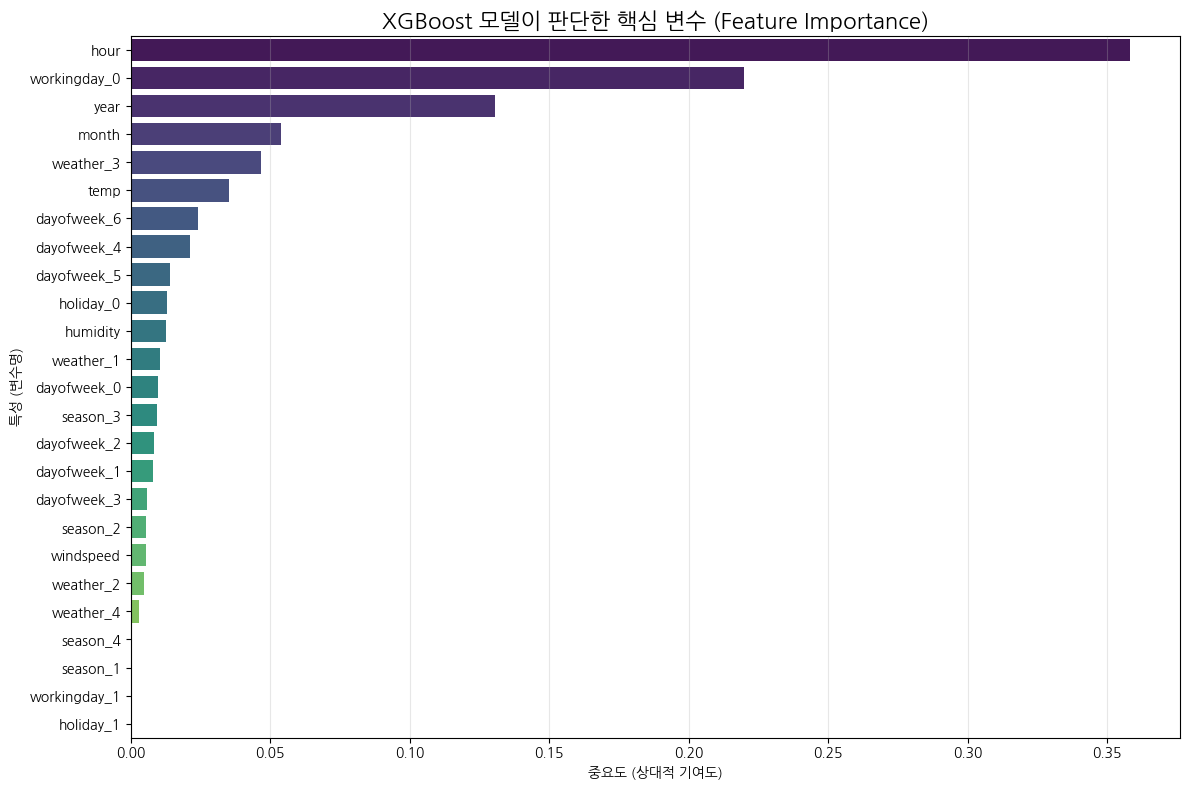

In [227]:
# XGBoost 모델에서 특성 중요도 추출
importances = final_model.feature_importances_

# 학습에 사용되었던 컬럼(변수) 이름들 추출
feature_names = x_full.columns

# 변수명과 중요도를 묶어 데이터프레임으로 만들고, 내림차순(큰 순서대로) 정렬
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 시각화 (수평 막대 그래프)
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df, hue='Feature', palette='viridis', legend=False)

plt.title('XGBoost 모델이 판단한 핵심 변수 (Feature Importance)', fontsize=16)
plt.xlabel('중요도 (상대적 기여도)')
plt.ylabel('특성 (변수명)')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 1) 시간대 별 자전거 대여 패턴

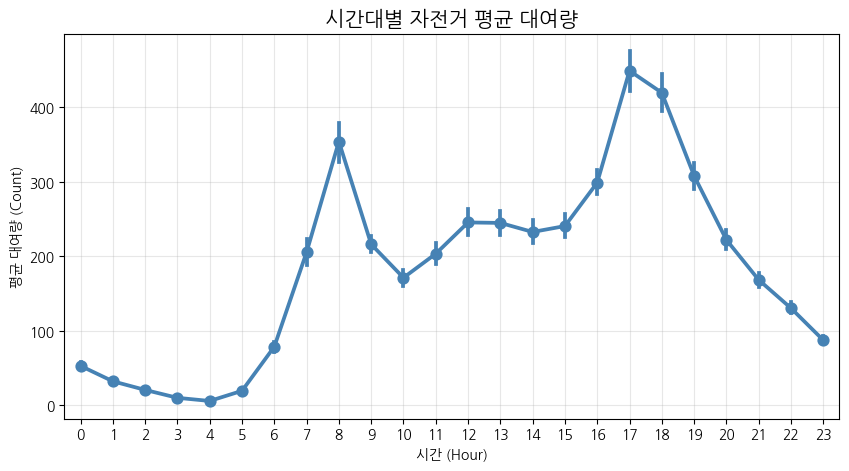

In [228]:
result_df = test_df.copy()
result_df['count'] = final_predict

result_df['datetime'] = pd.to_datetime(result_df['datetime'])
result_df['year'] = result_df['datetime'].dt.year
result_df['month'] = result_df['datetime'].dt.month
result_df['hour'] = result_df['datetime'].dt.hour
result_df['dayofweek'] = result_df['datetime'].dt.dayofweek

plt.figure(figsize=(10, 5))
sns.pointplot(data=result_df, x='hour', y='count', color='steelblue')
plt.title('시간대별 자전거 평균 대여량', fontsize=15)
plt.xlabel('시간 (Hour)')
plt.ylabel('평균 대여량 (Count)')
plt.grid(True, alpha=0.3)
plt.show()

### 2) 날씨 변수와 자전거 대여 수요 간의 상관관계

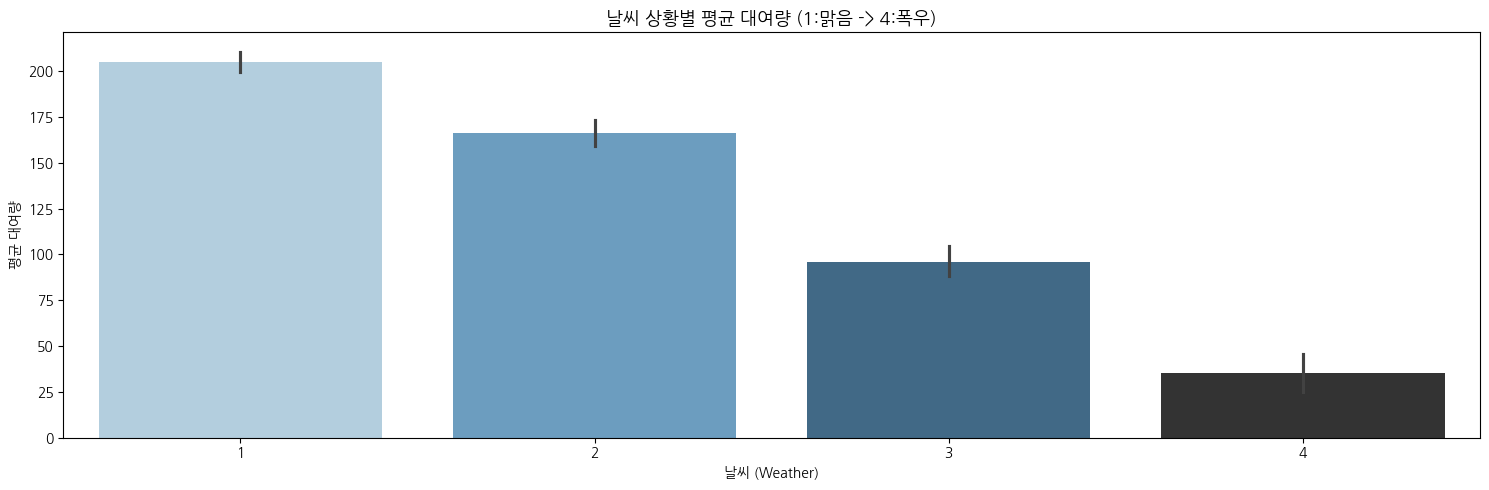

In [229]:
fig, axes = plt.subplots(1, 1, figsize=(15, 5))

# 날씨(weather) 범주에 따른 대여량
sns.barplot(data=result_df, x='weather', y='count', ax=axes, palette='Blues_d', hue='weather', legend=False)
axes.set_title('날씨 상황별 평균 대여량 (1:맑음 -> 4:폭우)', fontsize=13)
axes.set_xlabel('날씨 (Weather)')
axes.set_ylabel('평균 대여량')

plt.tight_layout()
plt.show()

### 3) 계절별 자전거 대여 패턴

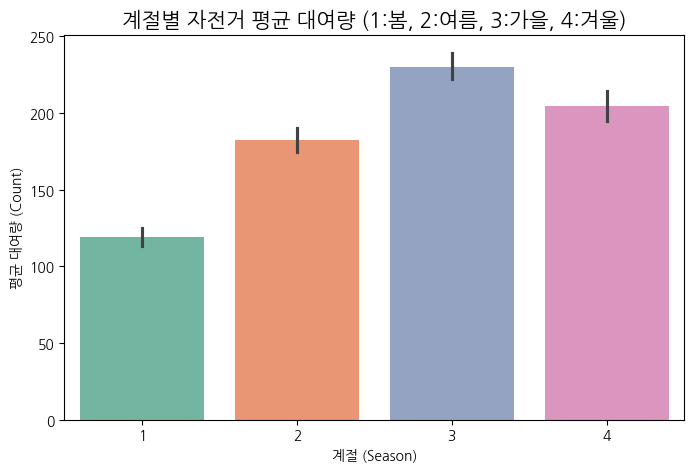

In [230]:
plt.figure(figsize=(8, 5))
sns.barplot(data=result_df, x='season', y='count', palette='Set2', hue='season', legend=False)
plt.title('계절별 자전거 평균 대여량 (1:봄, 2:여름, 3:가을, 4:겨울)', fontsize=15)
plt.xlabel('계절 (Season)')
plt.ylabel('평균 대여량 (Count)')
plt.show()

### 4) 주말과 평일의 자전거 대여 수요

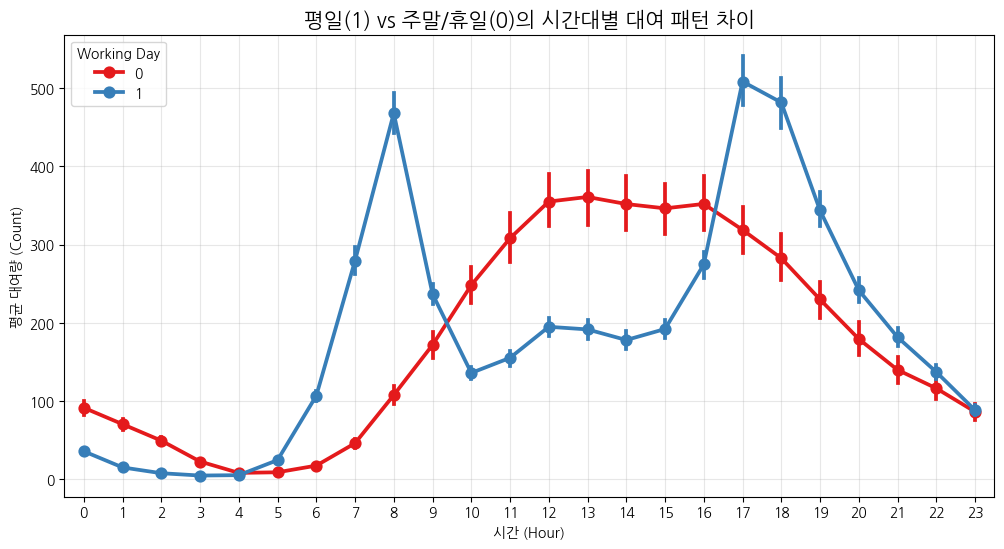

In [231]:
plt.figure(figsize=(12, 6))
# workingday: 1(평일), 0(주말 및 휴일)
sns.pointplot(data=result_df, x='hour', y='count', hue='workingday', palette='Set1')
plt.title('평일(1) vs 주말/휴일(0)의 시간대별 대여 패턴 차이', fontsize=15)
plt.xlabel('시간 (Hour)')
plt.ylabel('평균 대여량 (Count)')
plt.legend(title='Working Day', loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

앞서 분석했던 train_df와 대단히 유사하게 예측을 진행함을 확인할 수 있습니다.

## 12. 맺으며

지금까지 자전거 대여 데이터를 분석하여 예측 모델을 만들어보았습니다.  
데이터를 준비하고, 머신러닝 모델을 선정하여 최종적인 수요를 만들어내는 과정을  
최대한 명료하게 정리하면서도 최적의 성능을 드러내보고자 내용을 구성해 보았습니다.  

그 과정을 통해 다음과 같은 중요한 것들을 깨달을 수 있었습니다.
- 수치형 데이터의 결손을 RandomForest로 보간하는 방식이 효과적이다
- 타겟 컬럼(count) 역시 평가 지표(RMSLE)와 데이터의 분포 특성에 맞추어  
    로그 변환(np.log1p)과 같은 수학적 전처리를 거치면 모델의 학습 성능을 극대화할 수 있다
- 머신러닝은 수많은 종류가 있지만, 데이터의 특성에 따라 최적으로 작동하는 모델이 있다
- 경험적 하이퍼파라미터는 모델을 처음 평가할 때의 기준점이 된다
- 자동 하이퍼파라미터 탐색(GridSearchCV)은 한번에 많은 조합를 수행하는 것 보다  
    소량의 조합을 통해 성능 향상을 살펴 추론 후 최적을 찾아 나가는 것이 더 효율적이다.

본 분석 과정의 코드를 바탕으로 도출된 변수 간의 관계성 및 비즈니스 인사이트는  
별첨된 "자전거 대여 수요 예측 및 운영 전략 보고서(PDF)"에 상세히 수록하겠습니다.